# Game Player Analysis — revue Data Science finale

**Livrable principal exécuté.** L'objectif officiel est de prédire
`winRankPercentage`, le score de classement de l'équipe du joueur normalisé
entre 0 (dernière place) et 1 (première place), à partir de statistiques
post-partie. Une ligne décrit un joueur, tandis que la cible d'équipe est
répétée sur les joueurs observés de cette équipe.

Ce notebook privilégie la justesse des interprétations et la traçabilité :
chaque résultat modélisé est out-of-fold, le `gameId` est groupé, et le fichier
test officiel de mai reste sans labels et hors de toute sélection de modèle.

## 1. Cadre officiel, métrique et questions

- **Train :** 50 000 lignes attribuées à janvier–avril 2024.
- **Test :** 5 000 lignes attribuées à mai 2024.
- **Métrique principale :** MAE, complétée par RMSE et R².
- **Question modèle :** quelle précision post-match obtient-on avec les
  variables individuelles, et quelle part provient de `killRank` ?
- **Question produit :** les comportements mobilité, combat et ressources
  restent-ils informatifs sans le classement post-match ?

Le sujet affirme que `date` est la date du match. Cette définition sera testée,
pas supposée vraie. `maxRank` définit la grille de classement déclarée ; ce
n'est ni le nombre réel de joueurs ni le nombre de lignes observées par match.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/game-player-analysis-matplotlib")

import pandas as pd
from IPython.display import Image, Markdown, display

from game_player_analysis.inference import predict_frame
from game_player_analysis.logging_config import configure_logging
from game_player_analysis.pipeline import run_final_analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
configure_logging()

<Logger game_player_analysis (INFO)>

## 2. Exécution reproductible du pipeline

La cellule suivante repart des CSV bruts et exécute une seule chaîne commune :
validation, nettoyage, EDA, feature engineering, GroupKFold, quatre ensembles,
holdout groupé gelé, tuning borné, ablations, drift, diagnostics, modèle final,
manifeste et soumission. La seed de modélisation vaut 42 ; les empreintes
SHA-256 des données sont conservées dans le manifeste.

In [2]:
results = run_final_analysis(tuning_iterations=8)
tables = results["tables"]
display(Markdown(f"**Modèle publié : {results['winner']}**"))

2026-08-02T22:08:26 | INFO | game_player_analysis.pipeline | Loading and validating official train/test files
2026-08-02T22:08:27 | INFO | game_player_analysis.pipeline | Benchmarking defaults on development folds only
2026-08-02T22:09:32 | INFO | game_player_analysis.pipeline | Tuning fair-comparison winner CatBoost (8 trials)
2026-08-02T22:11:15 | INFO | game_player_analysis.pipeline | Evaluating frozen selection once on the cycle holdout
2026-08-02T22:11:18 | INFO | game_player_analysis.pipeline | Auditing feature families, splits, errors and interpretability
2026-08-02T22:12:57 | INFO | game_player_analysis.pipeline | Fitting and publishing CatBoost on all labeled rows
2026-08-02T22:13:02 | INFO | game_player_analysis.pipeline | Analysis complete: final holdout MAE 0.060797


**Modèle publié : CatBoost**

## 3. Chargement, contrat de données et nettoyage

In [3]:
display(tables["dataset_summary"])
display(tables["data_quality"].pivot(index="check", columns="dataset", values="rows"))

,train,test
rows,50000,5000
columns,30,29
matches,30983,4431
game_modes,16,10
missing_cells,0,0
exact_duplicates,0,0
date_min,2024-01-01 00:00:00,2024-05-01 00:00:00
date_max,2024-04-30 00:00:00,2024-05-31 00:00:00
has_target,True,False


dataset,test,train
check,,
combat_without_distance,5,102
exact_duplicates,0,0
invalid_gameId,10,93
invalid_playerId,14,93
invalid_teamId,8,87
killPts_conditional_zero,3000,29840
kills_without_damage,5,53
missing_cells,0,0
rankPts_-1,1888,19191


Il n'y a ni valeur manquante brute ni doublon exact. Cela ne signifie pas que
toutes les valeurs sont sémantiquement disponibles : `rankPts=-1` est une
sentinelle documentée ; `killPts=0` et `winPts=0` sont manquants lorsque le
système `rankPts` est actif. Le nettoyage les convertit en valeurs absentes et
ajoute des indicateurs, sans supprimer de ligne. Ces scores ne sont pas retenus
dans le modèle final, ce qui évite de mélanger plusieurs systèmes de ranking.

,dataset,check,rows,pct
2,train,invalid_playerId,93,0.186000
3,train,invalid_teamId,87,0.174000
4,train,invalid_gameId,93,0.186000
5,train,rankPts_-1,19191,38.382000
6,train,killPts_conditional_zero,29840,59.680000
7,train,winPts_conditional_zero,29840,59.680000
8,train,kills_without_damage,53,0.106000
9,train,combat_without_distance,102,0.204000
12,test,invalid_playerId,14,0.280000
13,test,invalid_teamId,8,0.160000


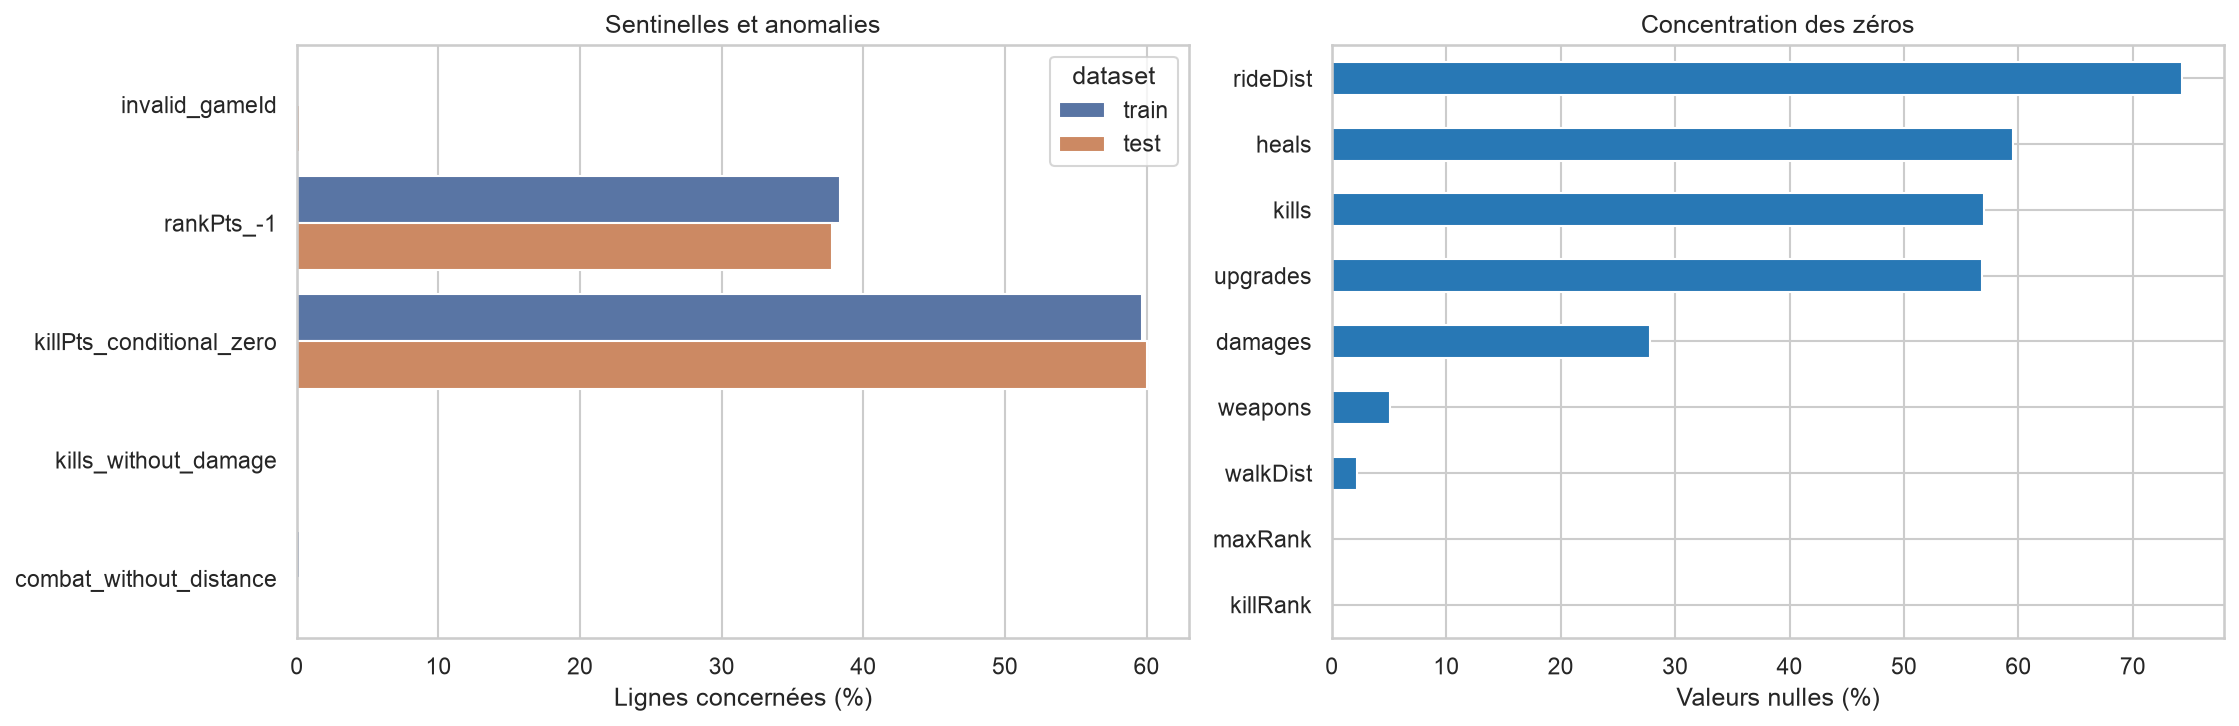

In [4]:
quality = tables["data_quality"]
display(quality.loc[quality["check"].str.contains("Pts|without|invalid")])
display(Image(filename=str(results["paths"]["figure_data_quality"])))

## 4. Audit de la date et de l'échantillonnage

,rows,valid_game_ids,games,multirow_games,multirow_games_with_multiple_dates_pct,median_within_game_span_days,p95_within_game_span_days,max_within_game_span_days,date_min,date_max,unique_dates
dataset,,,,,,,,,,,
train,50000,49907,30927,13464,100.000000,45.026931,99.528735,119.302646,2024-01-01,2024-04-30,50000
test,5000,4990,4425,521,100.000000,9.067814,22.930586,28.949790,2024-05-01,2024-05-31,5000


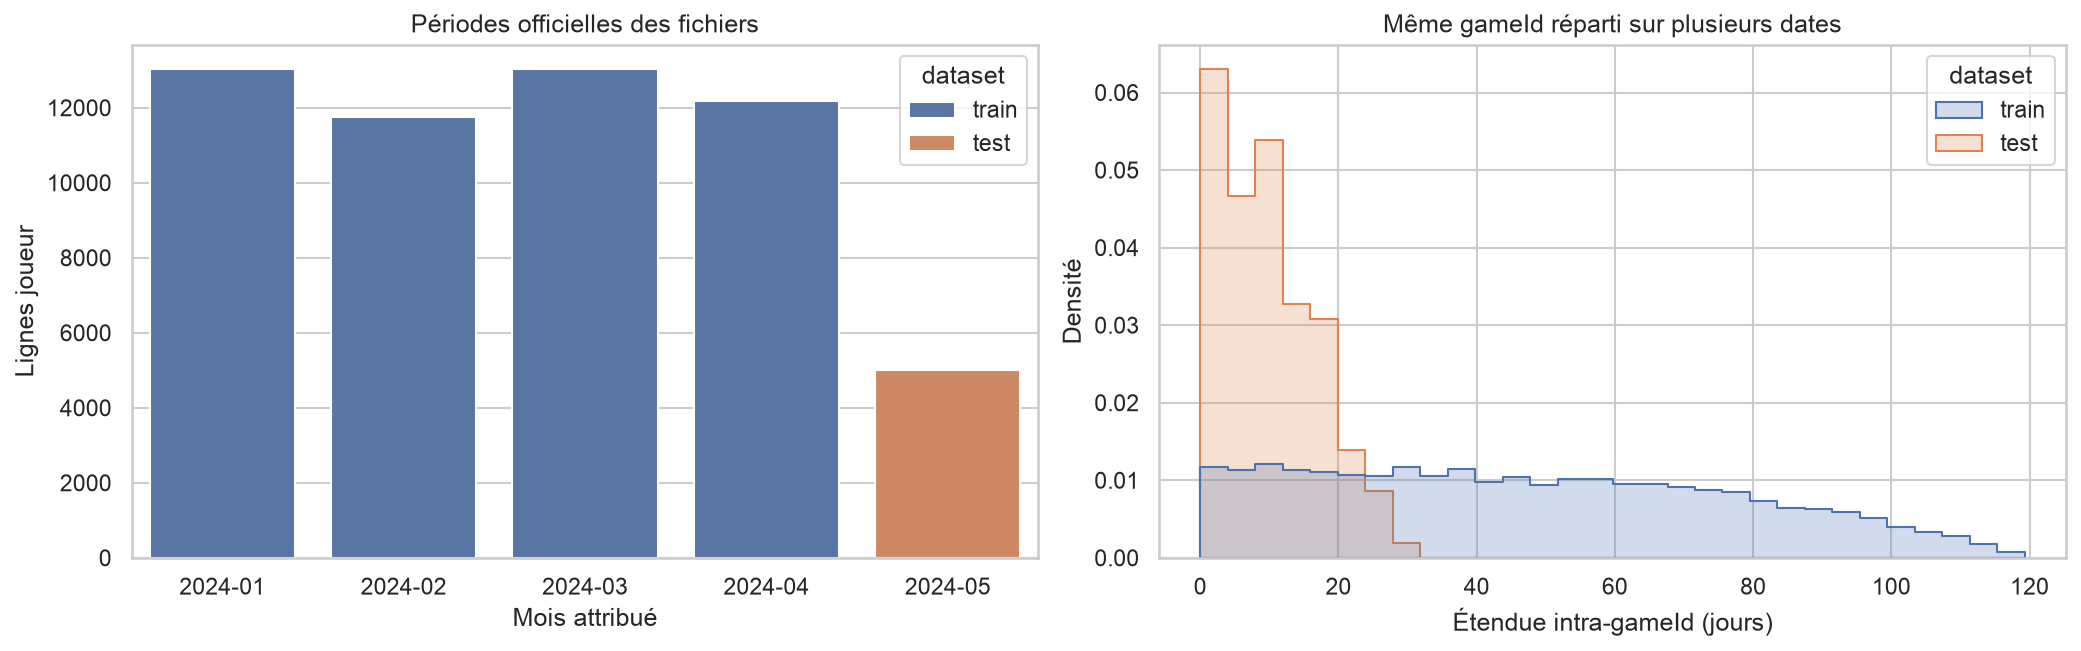

In [5]:
display(tables["date_integrity"])
display(Image(filename=str(results["paths"]["figure_date_integrity"])))

**Conclusion de l'audit temporel.** Pour 100 % des `gameId` valides ayant
plusieurs lignes, les dates diffèrent entre joueurs ; l'étendue médiane atteint
environ 45 jours dans le train. Les dates sont donc incompatibles avec la
définition officielle au niveau ligne. La cause technique n'est pas observable
dans les fichiers : on les qualifie d'incohérentes/corrompues, sans inventer une
explication. Le temps ne devient qu'un stress test pseudo-temporel.

,games,mean_observed_players_per_game,max_observed_players_per_game,observed_game_teams,singleton_team_pct,rows_with_observed_teammate_pct
dataset,,,,,,
train,30983,1.613788,8,49411,98.824148,2.340000
test,4431,1.128413,4,4974,99.477282,1.040000


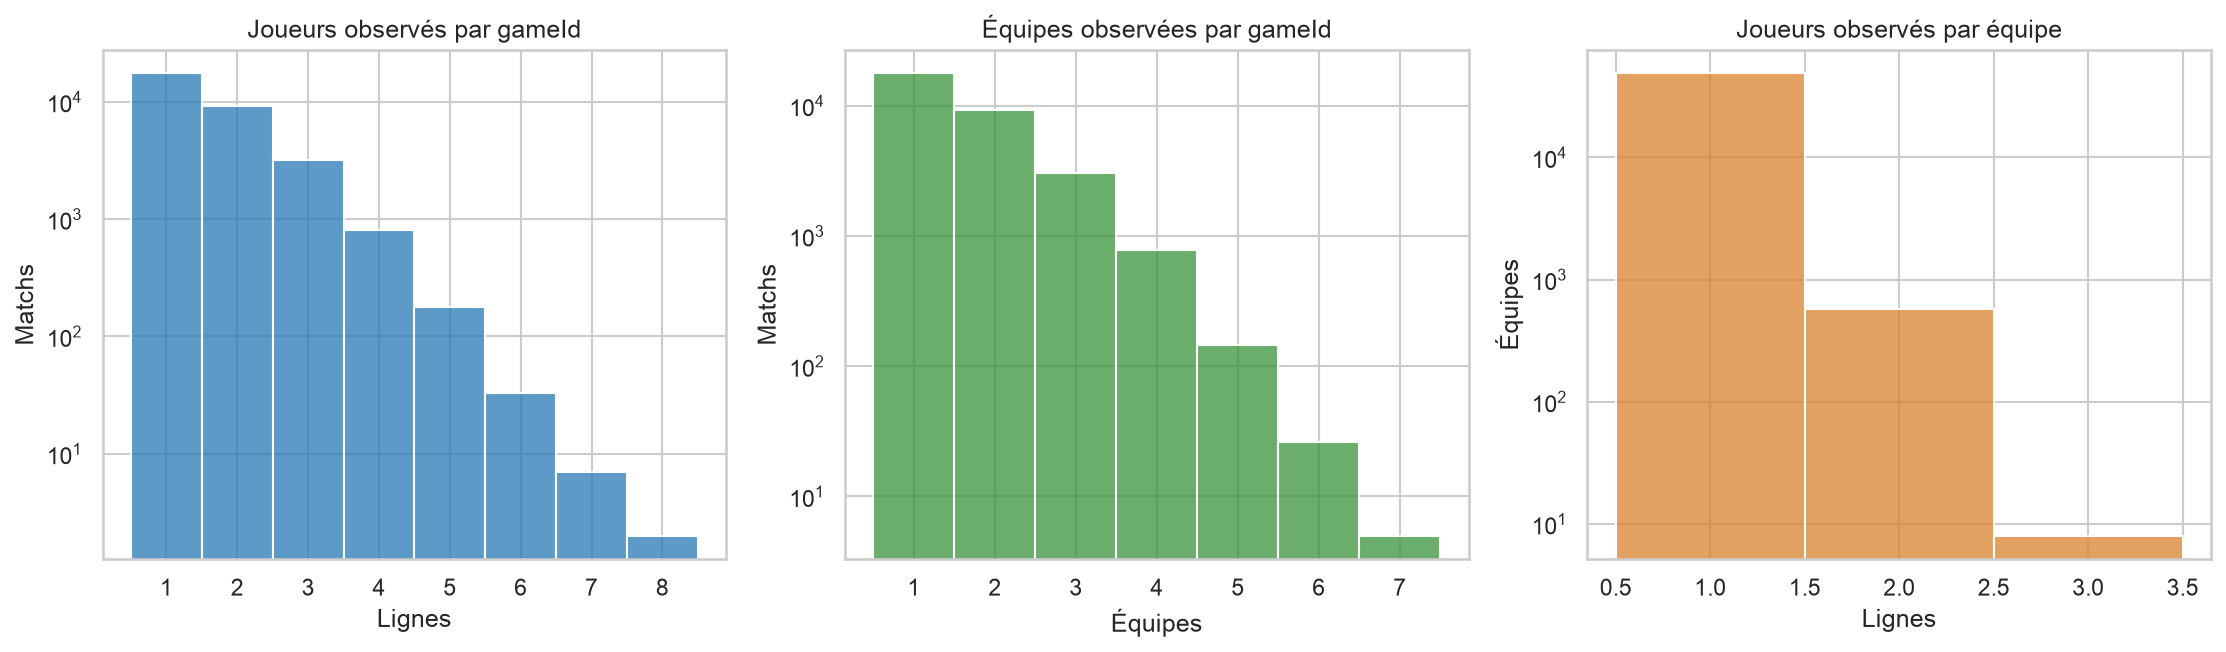

In [6]:
display(tables["sampling_coverage"])
display(Image(filename=str(results["paths"]["figure_sampling"])))

Seulement ~2,34 % des lignes train ont un coéquipier observé et près de 98,82 %
des groupes `(gameId, teamId)` sont des singletons. Les agrégats équipe/lobby
sont donc **rejetés** : ils mesureraient surtout le mécanisme d'échantillonnage,
pas la performance complète de l'équipe.

## 5. Drift train/test

,train_mean,test_mean,standardized_mean_difference,ks_statistic,ks_pvalue,psi,wasserstein_over_train_std,train_zero_pct,test_zero_pct,zero_pct_point_change,train_p95,test_p95
feature,,,,,,,,,,,,
damages,130.002242,126.041640,-0.023469,0.013120,0.410973,0.005085,0.029847,27.810000,27.280000,-0.530000,457.000000,444.725000
maxRank,44.396660,44.597000,0.008445,0.010040,0.745335,0.003538,0.010157,0.000000,0.000000,0.000000,97.000000,97.000000
resource_activity,6.145900,6.108800,-0.006921,0.010860,0.653128,0.002346,0.015860,5.078000,5.040000,-0.038000,17.000000,16.000000
walk_distance_per_match_minute,44.044220,43.966128,-0.001743,0.008060,0.926949,0.001807,0.008345,2.204000,2.280000,0.076000,130.776114,131.777471
weapons,3.664060,3.659200,-0.001971,0.010820,0.657677,0.001797,0.016649,5.116000,5.040000,-0.076000,8.000000,8.000000
killRank,47.576260,47.926600,0.012777,0.010140,0.734303,0.001051,0.013159,0.000000,0.000000,0.000000,91.000000,91.000000
walkDist,"1,155.221535","1,146.163054",-0.007655,0.008800,0.869905,0.001041,0.009669,2.204000,2.280000,0.076000,"3,384.000000","3,361.100000"
upgrades,1.104860,1.091400,-0.007858,0.007040,0.976760,0.000849,0.017643,56.864000,56.360000,-0.504000,5.000000,5.000000
damage_per_kill,53.572314,53.244604,-0.004424,0.004920,0.999881,0.000792,0.007814,57.072000,57.180000,0.108000,190.600000,189.905000


,psi,total_variation_distance,largest_shift_category,largest_percentage_point_change,train_unique,test_unique,test_only_categories
feature,,,,,,,
gameType,0.008441,0.010840,squad-fpp,0.506000,16,10,0
mode_family,0.001211,0.003900,squad,0.310000,4,4,0
ranking_system,0.000556,0.006220,legacy,-0.622000,3,3,0


method            standardized logistic adversarial validation
folds                                                        5
roc_auc_mean                                          0.493248
roc_auc_std                                           0.005420
roc_auc_min                                           0.484662
roc_auc_max                                           0.498847
interpretation                    weak multivariate separation
dtype: object

data_drift_train_vs_test                                measurable without target
performance_or_concept_drift    not measurable: official test target is unavai...
temporal_drift                    not interpretable: date conflicts within gameId
decision_rule                   effect sizes first; KS p-values are descriptiv...
dtype: object

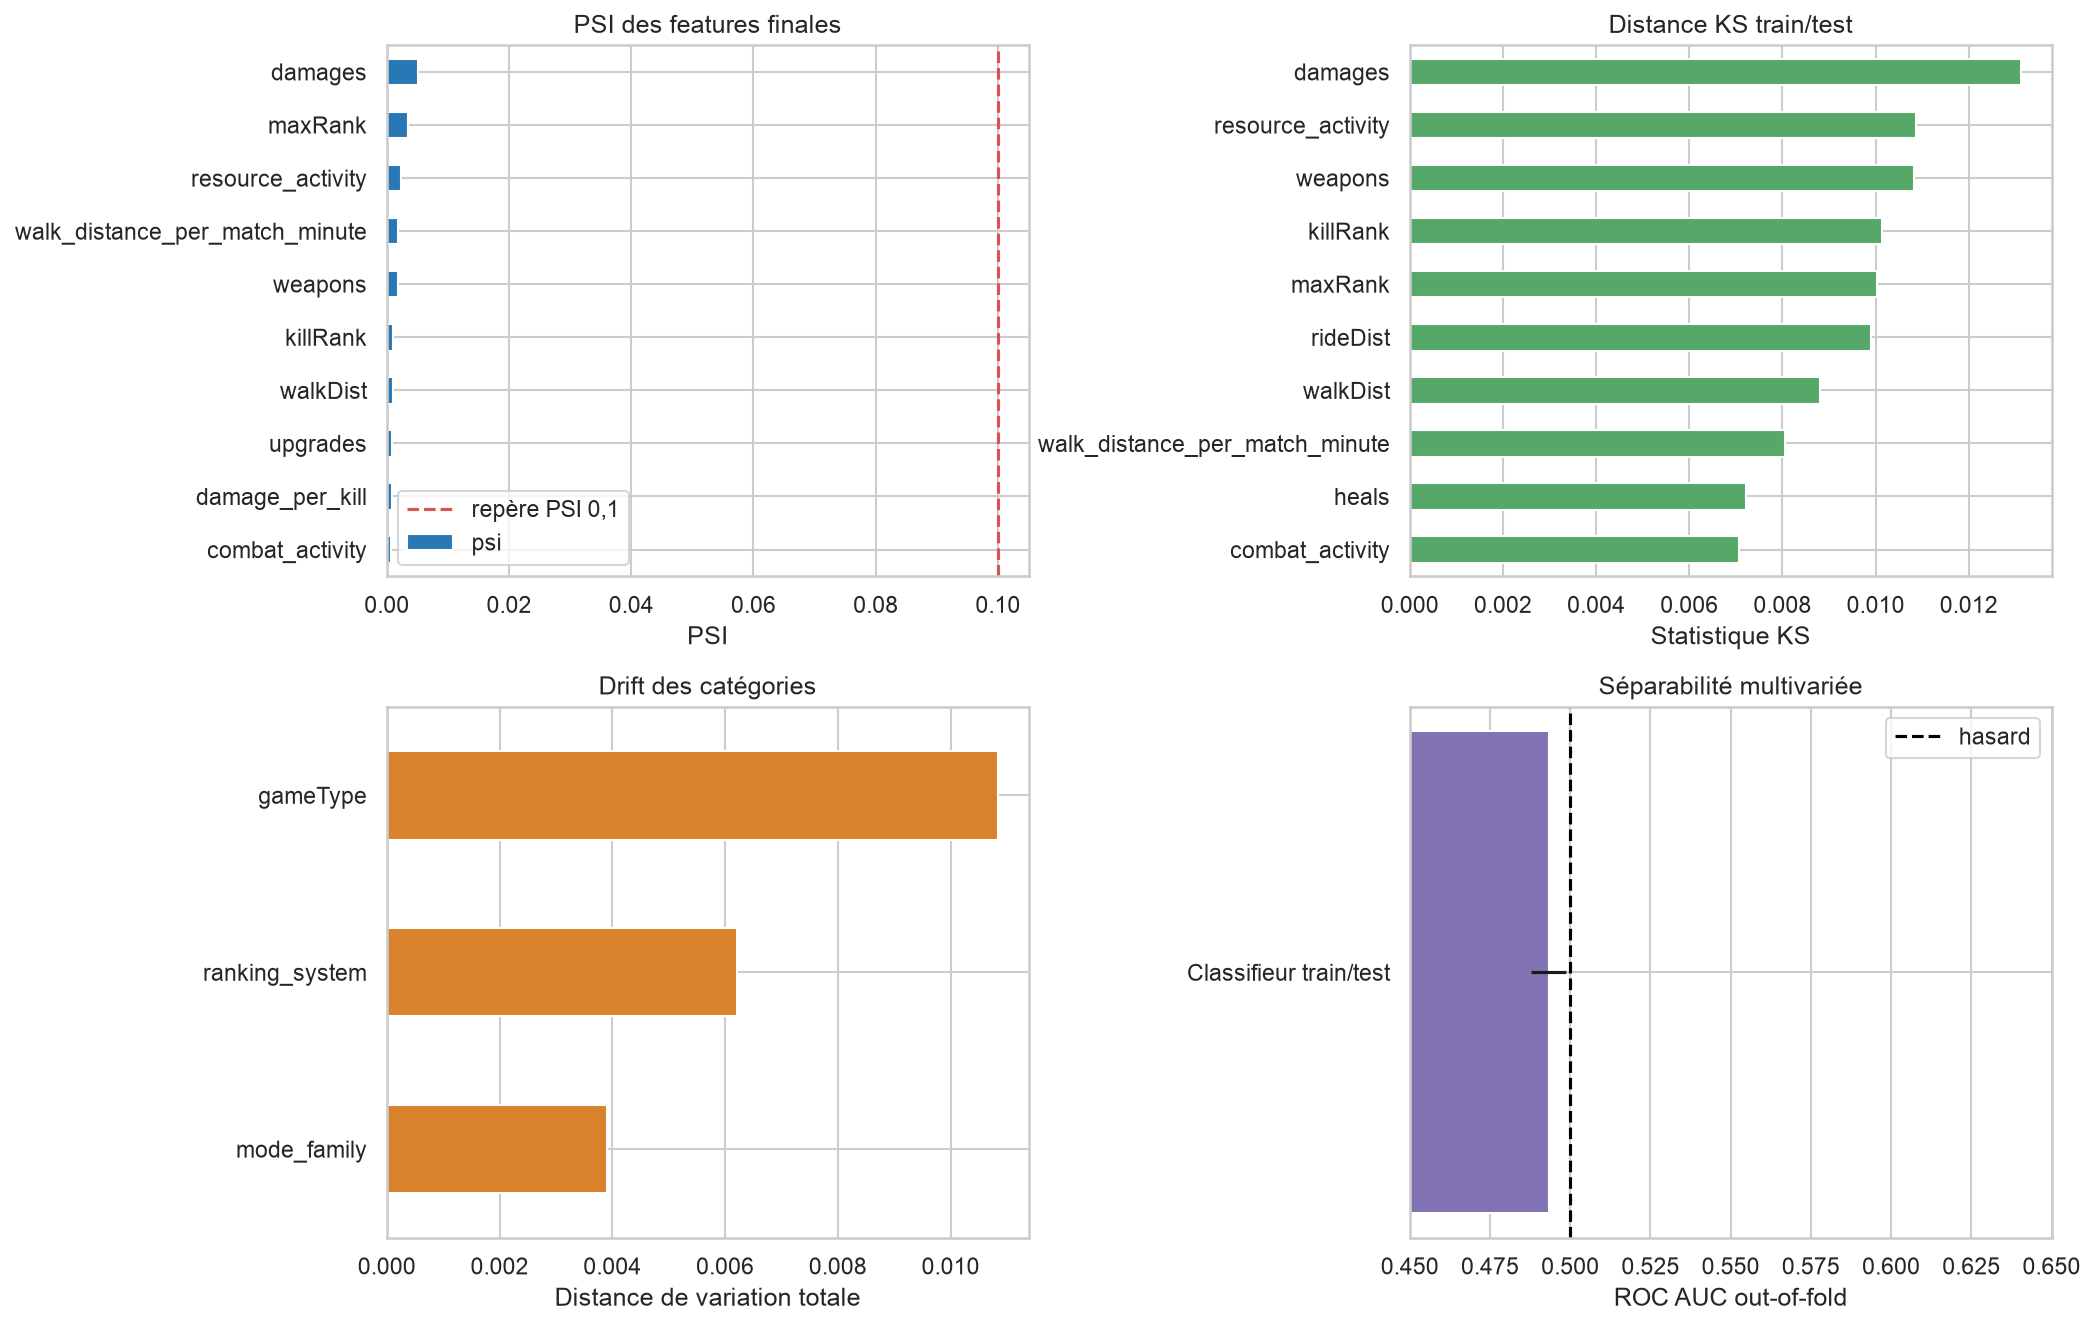

In [7]:
display(tables["distribution_shift"].head(16))
display(tables["categorical_shift"])
display(tables["adversarial_validation"])
display(tables["drift_limitations"])
display(Image(filename=str(results["paths"]["figure_drift"])))

Le drift est mesuré par PSI, KS, Wasserstein normalisée, variations de masse à
zéro, déplacements catégoriels et validation adversariale. Le PSI numérique
maximal vaut environ 0,0051, le PSI catégoriel maximal 0,0084 et le ROC AUC
adversarial 0,493 : aucune dérive matérielle n'est détectée sur le contrat de
features mesuré. Cela ne prouve pas l'identité des distributions. Sans cible
test, le drift de performance/concept reste inconnu ; avec la date incohérente,
le drift temporel n'est pas interprétable.

## 6. Analyse exploratoire et hypothèses

,valeur
target_mean,0.472333
target_median,0.457850
target_std,0.307449
target_zero_rows,"2,450.000000"
target_one_rows,"1,430.000000"
unique_target_values,"1,445.000000"
grid_distance_median,0.000800
grid_distance_p95,0.003200
grid_distance_max,0.005000
rows_within_0.0001_of_grid,"10,380.000000"


,zero_pct,mean,median,p95,p99,max,spearman_target
walkDist,2.204000,"1,155.221535",683.750000,"3,384.000000","4,395.020000","11,260.000000",0.866437
killRank,0.000000,47.576260,47.000000,91.000000,96.000000,100.000000,-0.714684
upgrades,56.864000,1.104860,0.000000,5.000000,7.000000,14.000000,0.681032
weapons,5.116000,3.664060,3.000000,8.000000,10.000000,73.000000,0.664606
heals,59.542000,1.376980,0.000000,7.000000,13.000000,41.000000,0.563679
damages,27.810000,130.002242,84.700000,457.000000,766.602000,"3,725.000000",0.449022
rideDist,74.258000,602.279772,0.000000,"4,032.000000","6,868.100000","31,290.000000",0.432890
kills,56.966000,0.921040,0.000000,4.000000,7.000000,35.000000,0.424812
maxRank,0.000000,44.396660,30.000000,97.000000,99.000000,100.000000,0.045750


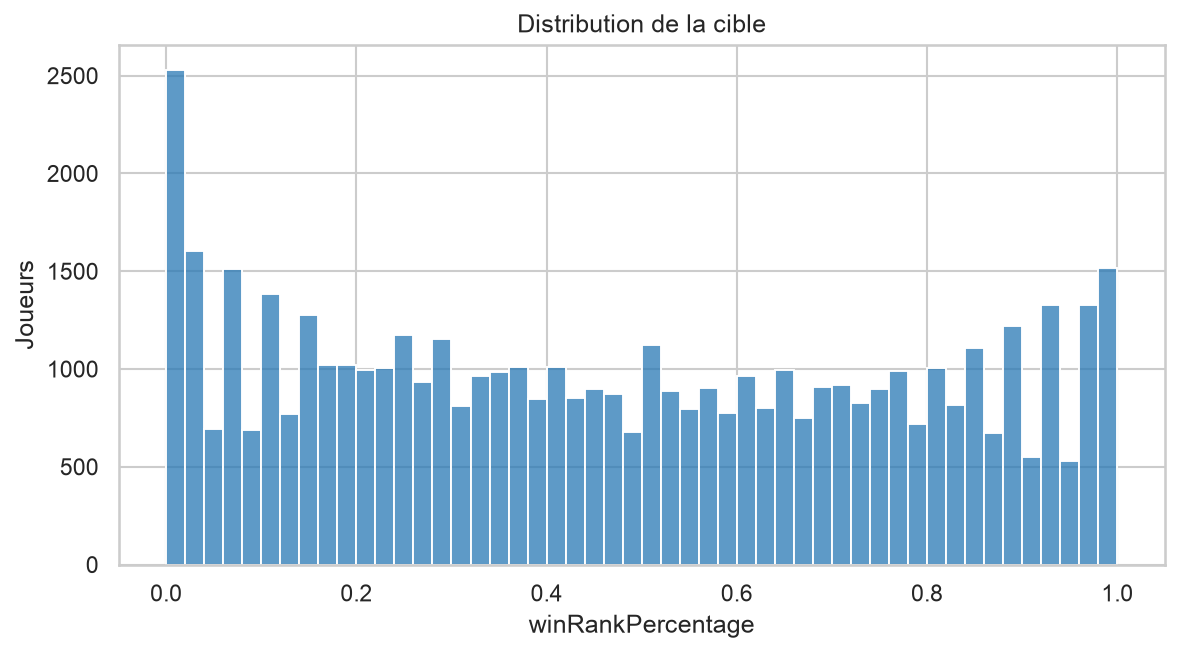

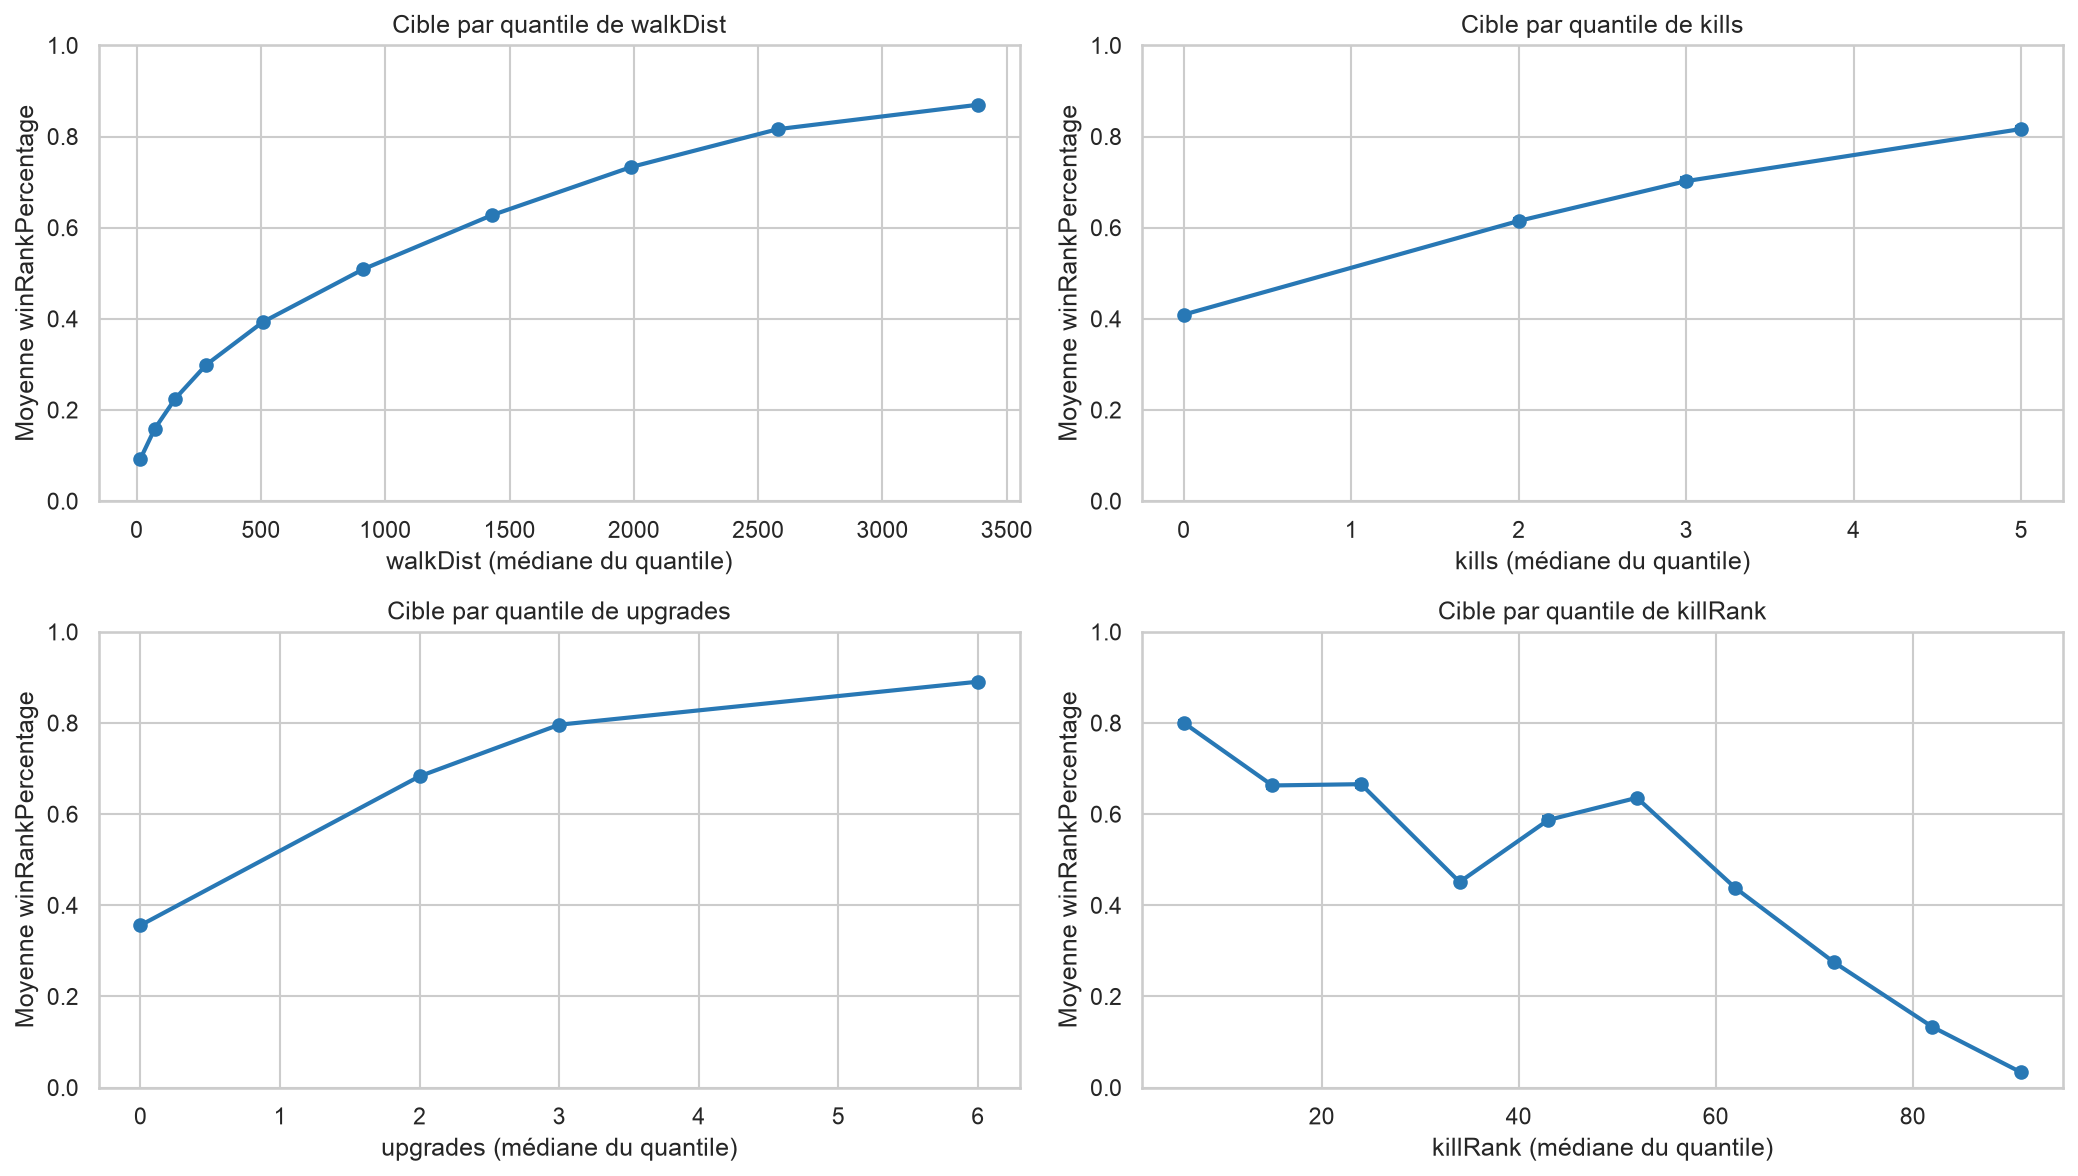

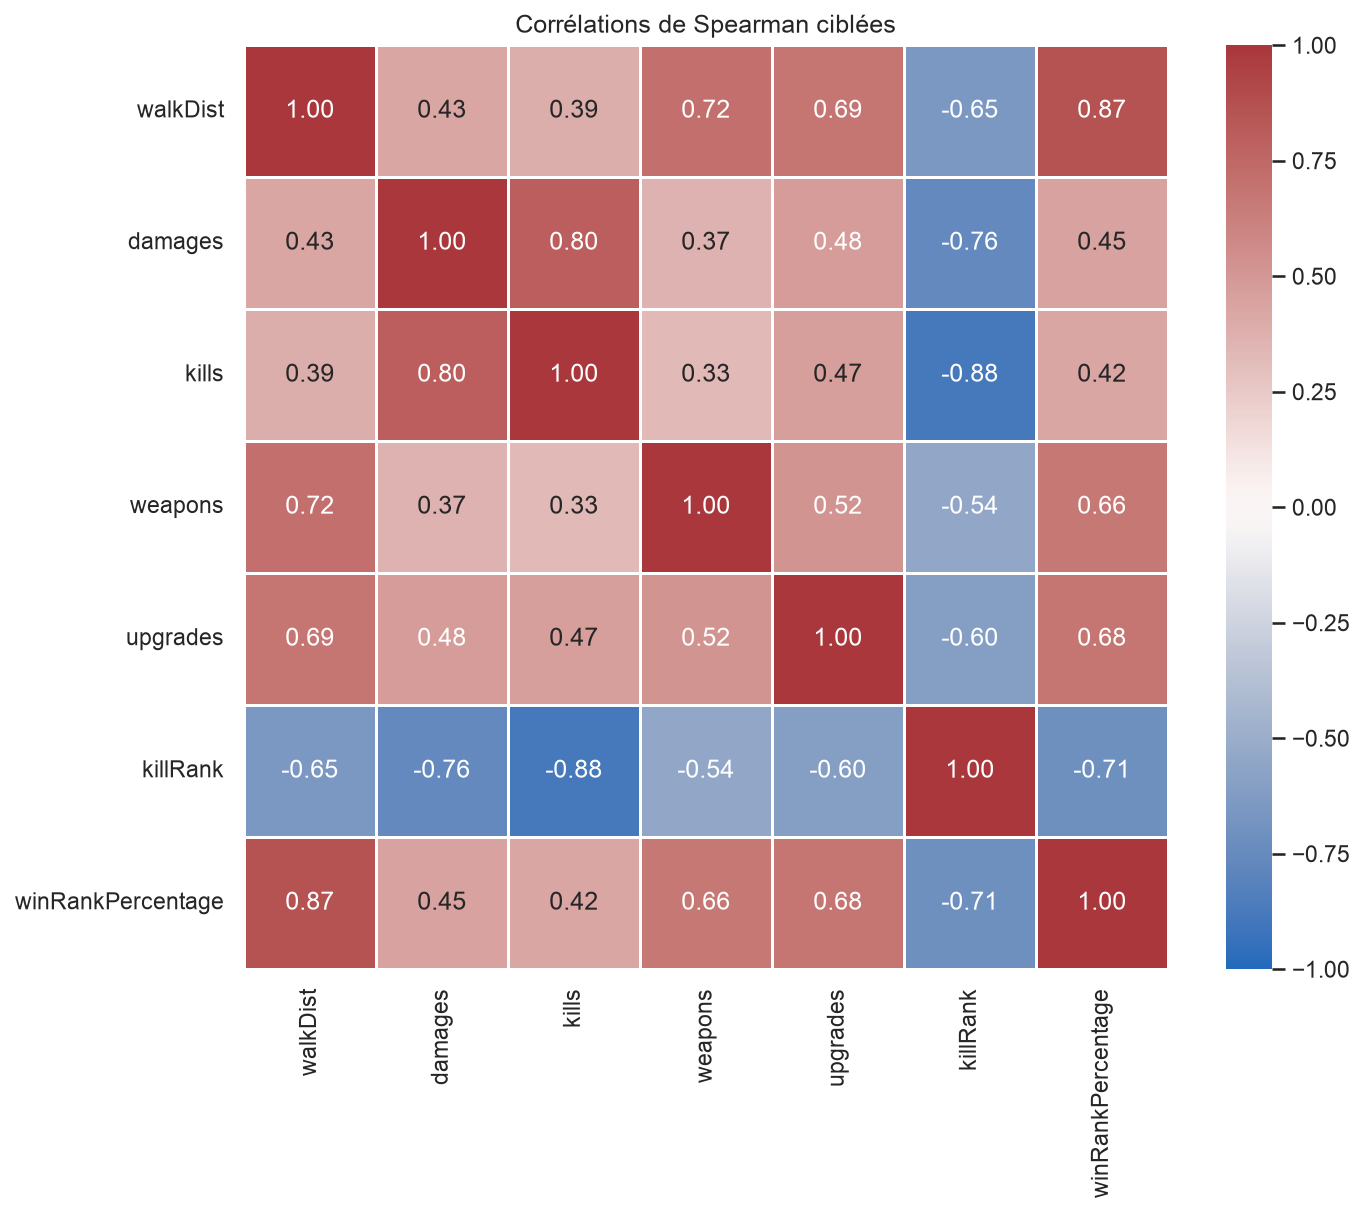

In [8]:
display(tables["target_grid"].to_frame("valeur"))
display(tables["numeric_profile"])
display(Image(filename=str(results["paths"]["figure_target"])))
display(Image(filename=str(results["paths"]["figure_profiles"])))
display(Image(filename=str(results["paths"]["figure_correlations"])))

Hypothèses examinées : (1) la mobilité reflète fortement la progression dans
la partie ; (2) combat et ressources ajoutent une information comportementale ;
(3) `killRank`, déjà calculé après le match, doit dominer le scénario post-match ;
(4) les modes changent l'échelle des comportements. Les profils par quantiles
et leurs intervalles à 95 % montrent les relations non linéaires ; la matrice
de Spearman reste ciblée pour ne pas masquer ces effets.

## 7. KPI analytiques

In [9]:
display(tables["kpi_evaluation"])

,formula,defined_pct,mean,median,p95,zero_pct_among_defined,spearman_target,most_redundant_source,max_abs_source_spearman,model_decision
kpi,,,,,,,,,,
total_distance,walkDist + rideDist + swimDist,100.000000,"1,761.907329",792.000000,"6,430.050000",2.136000,0.832147,walkDist,0.943067,analytic_only_redundant
mobility_per_match_second,total_distance / gameTime,100.000000,1.074005,0.510672,3.519943,2.136000,0.848123,total_distance,0.994194,analytic_only_match_time_not_survival
damage_per_kill_kpi,damages / kills; 0 when kills=0,100.000000,53.572314,0.000000,190.600000,57.072000,0.369443,kills,0.890303,candidate_requires_ablation
headshot_ratio,headshots / kills; undefined when kills=0,43.034000,0.236041,0.000000,1.000000,61.026165,0.106378,headshots,0.942995,analytic_only_sparse
combat_activity_kpi,kills + assists + knocks,100.000000,1.809560,1.000000,7.000000,45.468000,0.429753,kills,0.900159,candidate_requires_ablation
resource_activity_kpi,weapons + upgrades + heals,100.000000,6.145900,5.000000,17.000000,5.078000,0.771366,weapons,0.861983,candidate_requires_ablation
support_actions,assists + revives,100.000000,0.396940,0.000000,2.000000,74.168000,0.363548,assists,0.794826,analytic_only_mode_dependent


Chaque ratio a une règle explicite pour les dénominateurs nuls. Les KPI
`total_distance`, mobilité/seconde et headshot ratio restent descriptifs car
ils sont redondants, utilisent `gameTime` qui n'est pas un temps de survie, ou
sont trop clairsemés. `damage_per_kill`, `combat_activity` et
`resource_activity` entrent dans l'ablation : leur maintien dépend de leur gain
mesuré, pas de leur plausibilité seule.

## 8. Features et ablation progressive

,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting,mae_gain_vs_previous
stage,,,,,,,,,,,,,,,,
1. context,1. context,0.267714,0.000952,0.266690,0.269146,0.307390,0.001036,-0.000213,0.001589,0.266685,0.001029,10.362321,0.022949,4,faible écart,NaN
2. + mobility,2. + mobility,0.098414,0.000535,0.097895,0.099322,0.134965,0.001694,0.807144,0.005261,0.093079,0.005335,12.150959,0.029034,7,écart modéré,0.169300
3. + combat,3. + combat,0.095515,0.000438,0.095236,0.096281,0.131921,0.001526,0.815748,0.004791,0.088753,0.006762,14.719648,0.028295,11,écart modéré,0.002899
4. + resources,4. + resources,0.092661,0.000665,0.092060,0.093755,0.129242,0.001801,0.823144,0.005416,0.085183,0.007478,15.017373,0.032702,15,écart modéré,0.002854
5. + killRank post-match,5. + killRank post-match,0.061500,0.001126,0.060768,0.063369,0.086609,0.001917,0.920562,0.003629,0.055258,0.006243,15.957211,0.032321,16,écart modéré,0.031161


,mae,rmse,r2,features
scenario,,,,
post_match_with_killRank,0.061448,0.086477,0.920845,16
behavior_without_killRank,0.092661,0.129242,0.823144,15
post_match_grid_snapped,0.060982,0.086882,0.920102,16


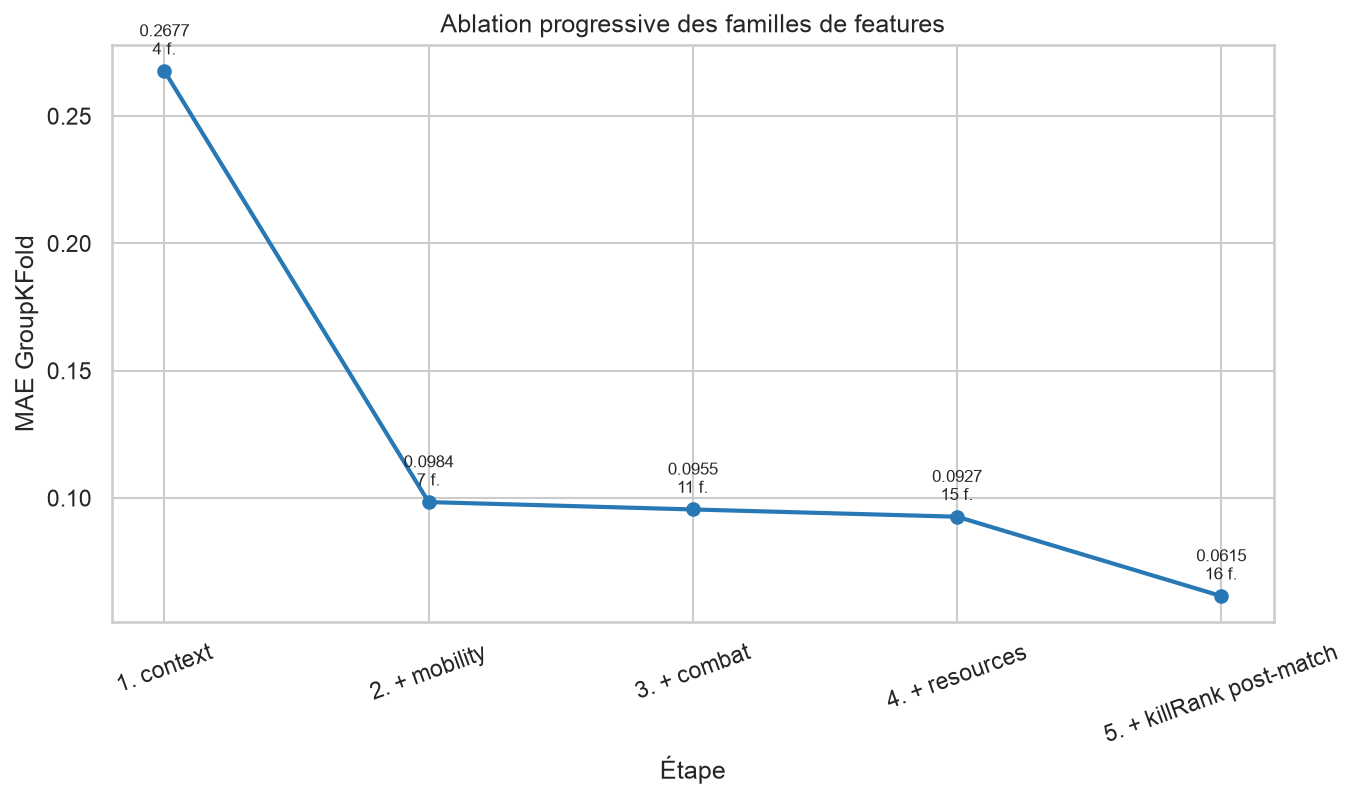

In [10]:
display(tables["feature_ablation"].set_index("stage"))
display(tables["scenario_comparison"].set_index("scenario"))
display(Image(filename=str(results["paths"]["figure_ablation"])))

La mobilité produit le principal gain comportemental ; combat et ressources
améliorent ensuite modestement la MAE. L'ajout de `killRank` fait passer la MAE
d'environ 0,0927 à 0,0615 : le modèle publié est donc explicitement un modèle
**post-match**, et non une prédiction early-game. La projection sur la grille
`maxRank` améliore légèrement la MAE mais dégrade le RMSE ; elle est réservée à
la soumission, avec cette contrepartie documentée.

## 9. Validation et contrôles de fuite

,fold,train_rows,validation_rows,shared_groups,shared_raw_game_ids,invalid_train_rows,invalid_validation_rows
0,1,32102,8026,0,0,59,17
1,2,32102,8026,0,0,59,17
2,3,32102,8026,0,0,62,14
3,4,32103,8025,0,0,62,14
4,5,32103,8025,0,0,62,14


,train_rows,validation_rows,shared_groups,shared_raw_game_ids,validation_rows_from_seen_games_pct,train_date_min,train_date_max,validation_date_min,validation_date_max
strategy,,,,,,,,,
Random row,40000,10000,5114,5114,56.640000,2024-01-01,2024-04-30 00:00:00.000000000,2024-01-01 00:13:42.544450889,2024-04-29 23:36:00.547210944
Grouped gameId,39901,10099,0,0,0.000000,2024-01-01,2024-04-29 23:56:34.363887278,2024-01-01 00:10:16.908338166,2024-04-30 00:00:00.000000000
Naive Jan-Mar → Apr,37815,12185,5908,5908,54.969224,2024-01-01,2024-03-31 23:58:43.966479330,2024-04-01 00:02:09.602592052,2024-04-30 00:00:00.000000000
Purged Jan-Mar → Apr,29279,12185,0,0,0.000000,2024-01-01,2024-03-31 23:58:43.966479330,2024-04-01 00:02:09.602592052,2024-04-30 00:00:00.000000000


,train_rows,validation_rows,train_mae,mae,rmse,r2,fit_seconds,predict_seconds
strategy,,,,,,,,
Random row,40000,10000,0.055854,0.060949,0.085371,0.923908,3.434400,0.010344
Grouped gameId,39901,10099,0.055730,0.061160,0.085936,0.921702,3.454899,0.010229
Naive Jan-Mar → Apr,37815,12185,0.055663,0.060944,0.085253,0.923750,3.379563,0.011207
Purged Jan-Mar → Apr,29279,12185,0.054965,0.061277,0.085688,0.922970,2.876210,0.010529


,train_rows,validation_rows,shared_groups,shared_raw_game_ids,validation_rows_from_seen_games_pct,train_date_min,train_date_max,validation_date_min,validation_date_max
strategy,,,,,,,,,
Final cycle holdout,40128,9872,0,0,0.000000,2024-01-01,2024-04-30,2024-01-01 00:03:25.636112722,2024-04-29 23:42:51.819436390


,model,development_rows,holdout_rows,train_mae,mae,rmse,r2,mae_gap,fit_seconds,predict_seconds,shared_games,decision_frozen_before_holdout,historical_limitation
0,CatBoost,40128,9872,0.055770,0.060797,0.086596,0.920827,0.005027,3.597430,0.008715,0,True,"independent of this audit cycle, but earlier E..."


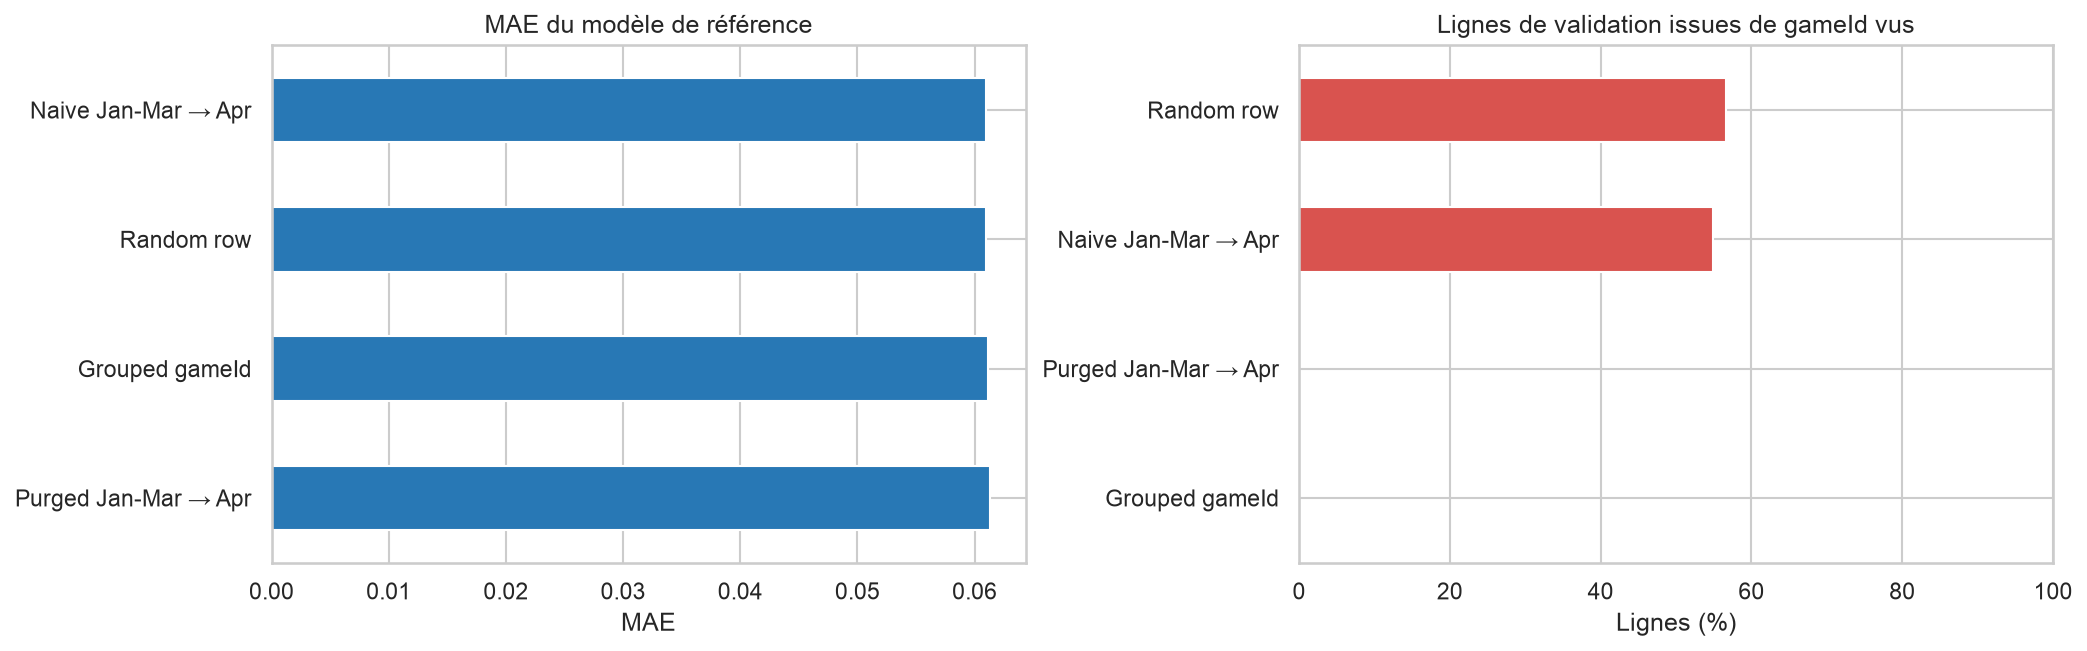

In [11]:
display(tables["fold_audit"])
display(tables["holdout_audit"])
display(tables["holdout_performance"])
display(tables["final_holdout_audit"])
display(tables["final_holdout_evaluation"])
display(Image(filename=str(results["paths"]["figure_validation"])))

Un holdout groupé est gelé avant la sélection. Les 40 128 lignes restantes
alimentent le GroupKFold à 5 folds ; les valeurs malformées répétées sont
groupées conservativement et aucun identifiant ne traverse une partition. Un
split aléatoire de lignes expose plus de la moitié de sa validation à des matchs
déjà vus. Le stress test Jan–mars → avril reste non chronologique puisque
`date` est incohérente. Après gel de la décision, CatBoost atteint environ
0,06080 de MAE sur les 9 872 lignes du holdout du cycle.

## 10. Justification du nombre de folds

,CatBoost,XGBoost,mae_std,mae_standard_error,mean_validation_rows,catboost_winning_folds,fit_cost_relative_to_5_folds
n_splits,,,,,,,
3,0.061564,0.063748,0.000698,0.000403,"13,376.000000",3,0.534288
5,0.061448,0.063448,0.001095,0.000490,"8,025.600000",5,1.000000
7,0.061260,0.063488,0.000873,0.000330,"5,732.571429",7,1.577751
10,0.061368,0.063318,0.001354,0.000428,"4,012.800000",10,2.142243


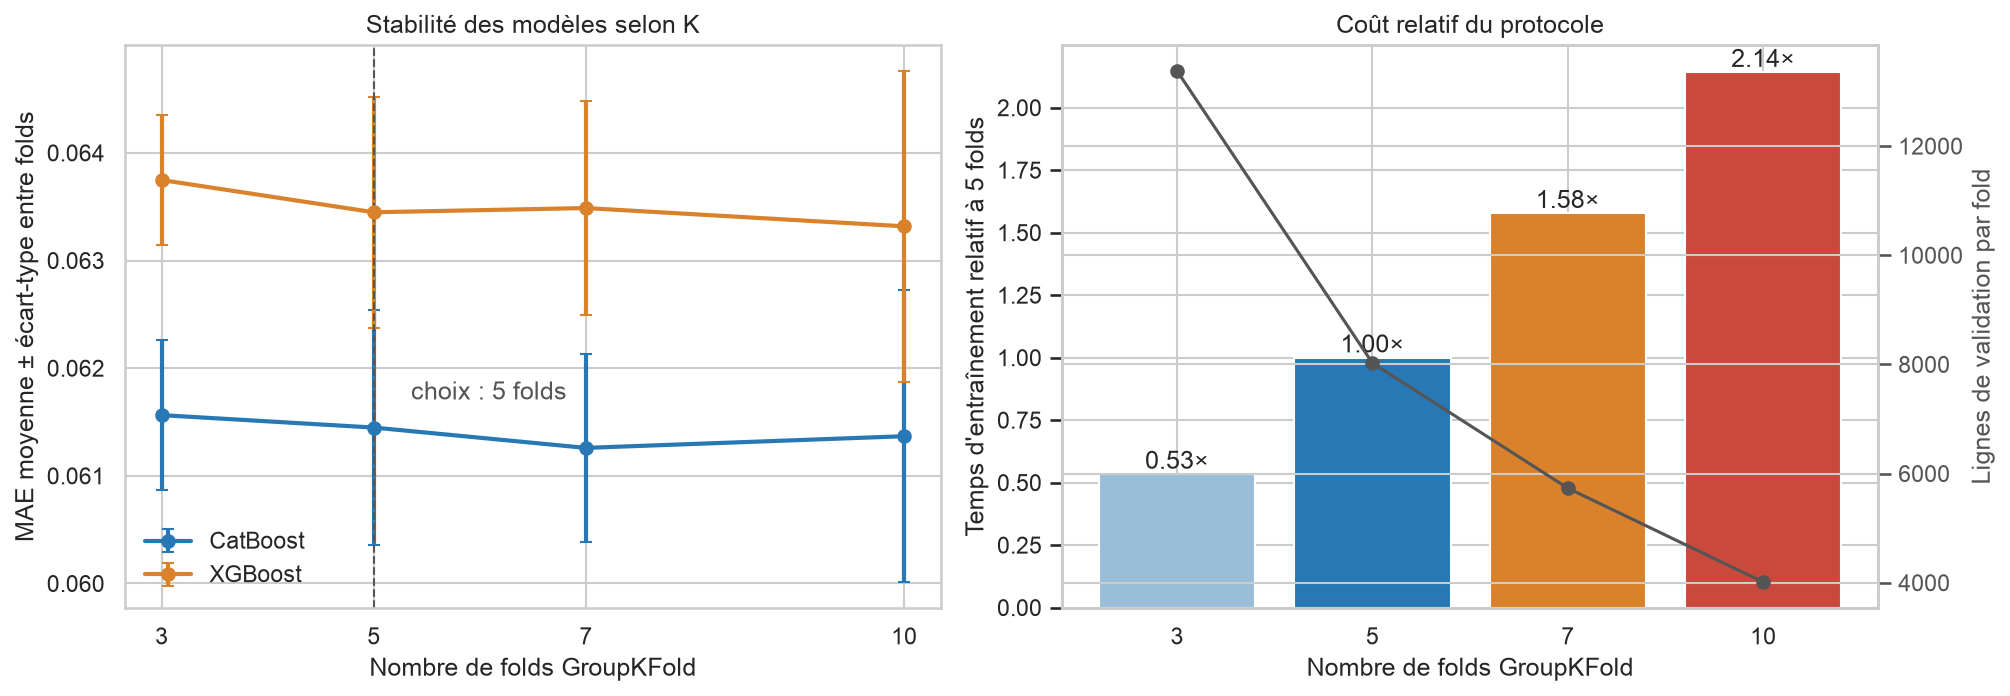

In [12]:
fold_metrics_path = PROJECT_ROOT / "artifacts" / "metrics" / "fold_count_sensitivity.csv"
fold_decision_path = PROJECT_ROOT / "artifacts" / "metrics" / "fold_count_decision.csv"
fold_figure_path = PROJECT_ROOT / "artifacts" / "figures" / "07c_fold_count_sensitivity.png"
if not (fold_metrics_path.exists() and fold_decision_path.exists() and fold_figure_path.exists()):
    from scripts.run_fold_count_study import main as run_fold_count_study

    run_fold_count_study()

fold_sensitivity = pd.read_csv(fold_metrics_path)
fold_decision = pd.read_csv(fold_decision_path)
fold_comparison = (
    fold_sensitivity.pivot(index="n_splits", columns="model", values="mae")
    .join(fold_sensitivity.loc[fold_sensitivity["model"].eq("CatBoost")].set_index("n_splits")[
        ["mae_std", "mae_standard_error", "mean_validation_rows"]
    ])
    .join(fold_decision.set_index("n_splits")[
        ["catboost_winning_folds", "fit_cost_relative_to_5_folds"]
    ])
)
display(fold_comparison)
display(Image(filename=str(fold_figure_path)))

L'étude compare `GroupKFold` avec K=3, 5, 7 et 10 sur les mêmes 40 128 lignes
de développement ; le holdout final reste fermé. CatBoost gagne XGBoost dans
les 25 folds cumulés. Sept folds affiche une MAE nominalement plus basse que
cinq (gain de **0,000189**), mais cet écart est inférieur à l'erreur standard
des folds et provient aussi d'apprentissages mécaniquement plus grands.

**Décision : 5 folds.** Chaque validation conserve environ 8 026 lignes de
matchs indépendants, la décision CatBoost est déjà stable dans les cinq folds,
et sept folds alourdit sensiblement le calcul. Dix folds double au moins la
charge mesurée, réduit la validation à environ 4 013 lignes et augmente la
dispersion. Le ratio de temps exact dépend de la machine ; il est affiché dans
la figure. Choisir K=7 uniquement parce que son score affiché est le plus faible
reviendrait à optimiser le protocole après observation des résultats.

## 11. Baselines et comparaison initiale

,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting
rank,,,,,,,,,,,,,,,
1,CatBoost,0.061448,0.001095,0.060766,0.063341,0.086460,0.001895,0.920835,0.003616,0.055269,0.006180,14.675677,0.032251,16,écart modéré
2,XGBoost,0.063448,0.001073,0.062617,0.065308,0.089602,0.001737,0.914989,0.003288,0.050440,0.013009,1.301037,0.037794,16,écart élevé
3,LightGBM,0.063593,0.000912,0.063063,0.065216,0.089087,0.001427,0.915970,0.002741,0.059488,0.004105,3.395280,0.087961,16,écart modéré
4,Random Forest,0.066677,0.000771,0.066054,0.068012,0.094343,0.001460,0.905764,0.002954,0.024722,0.041955,24.541611,0.318973,16,écart élevé
5,Linear Ridge baseline,0.088310,0.001395,0.086679,0.090082,0.122248,0.001965,0.841775,0.004876,0.088256,0.000054,0.058750,0.007811,16,faible écart
6,Median baseline,0.267877,0.000822,0.267188,0.269101,0.307808,0.001005,-0.002935,0.001421,0.267862,0.000016,0.000000,0.000000,16,non applicable
7,Mean baseline,0.268151,0.000792,0.267432,0.269250,0.307374,0.000920,-0.000112,0.000142,0.268143,0.000008,0.000000,0.000000,16,non applicable


,reference_model,candidate_model,folds,mean_mae_difference,ci95_lower,ci95_upper,candidate_worse_folds
0,CatBoost,XGBoost,5,0.002000,0.001829,0.002192,5
1,CatBoost,LightGBM,5,0.002144,0.001920,0.002369,5
2,CatBoost,Random Forest,5,0.005229,0.004917,0.005513,5
3,CatBoost,Linear Ridge baseline,5,0.026862,0.026301,0.027506,5
4,CatBoost,Median baseline,5,0.206429,0.205216,0.207402,5
5,CatBoost,Mean baseline,5,0.206703,0.205360,0.207708,5


,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting
1,XGBoost pre-audit custom,0.061999,0.001053,0.061296,0.063836,0.087360,0.001885,0.919182,0.003562,0.051368,0.010631,6.275185,0.111437,16,écart modéré
0,CatBoost pre-audit custom,0.062053,0.001187,0.061221,0.063976,0.087117,0.001894,0.919629,0.003612,0.058519,0.003533,11.359108,0.026675,16,écart modéré


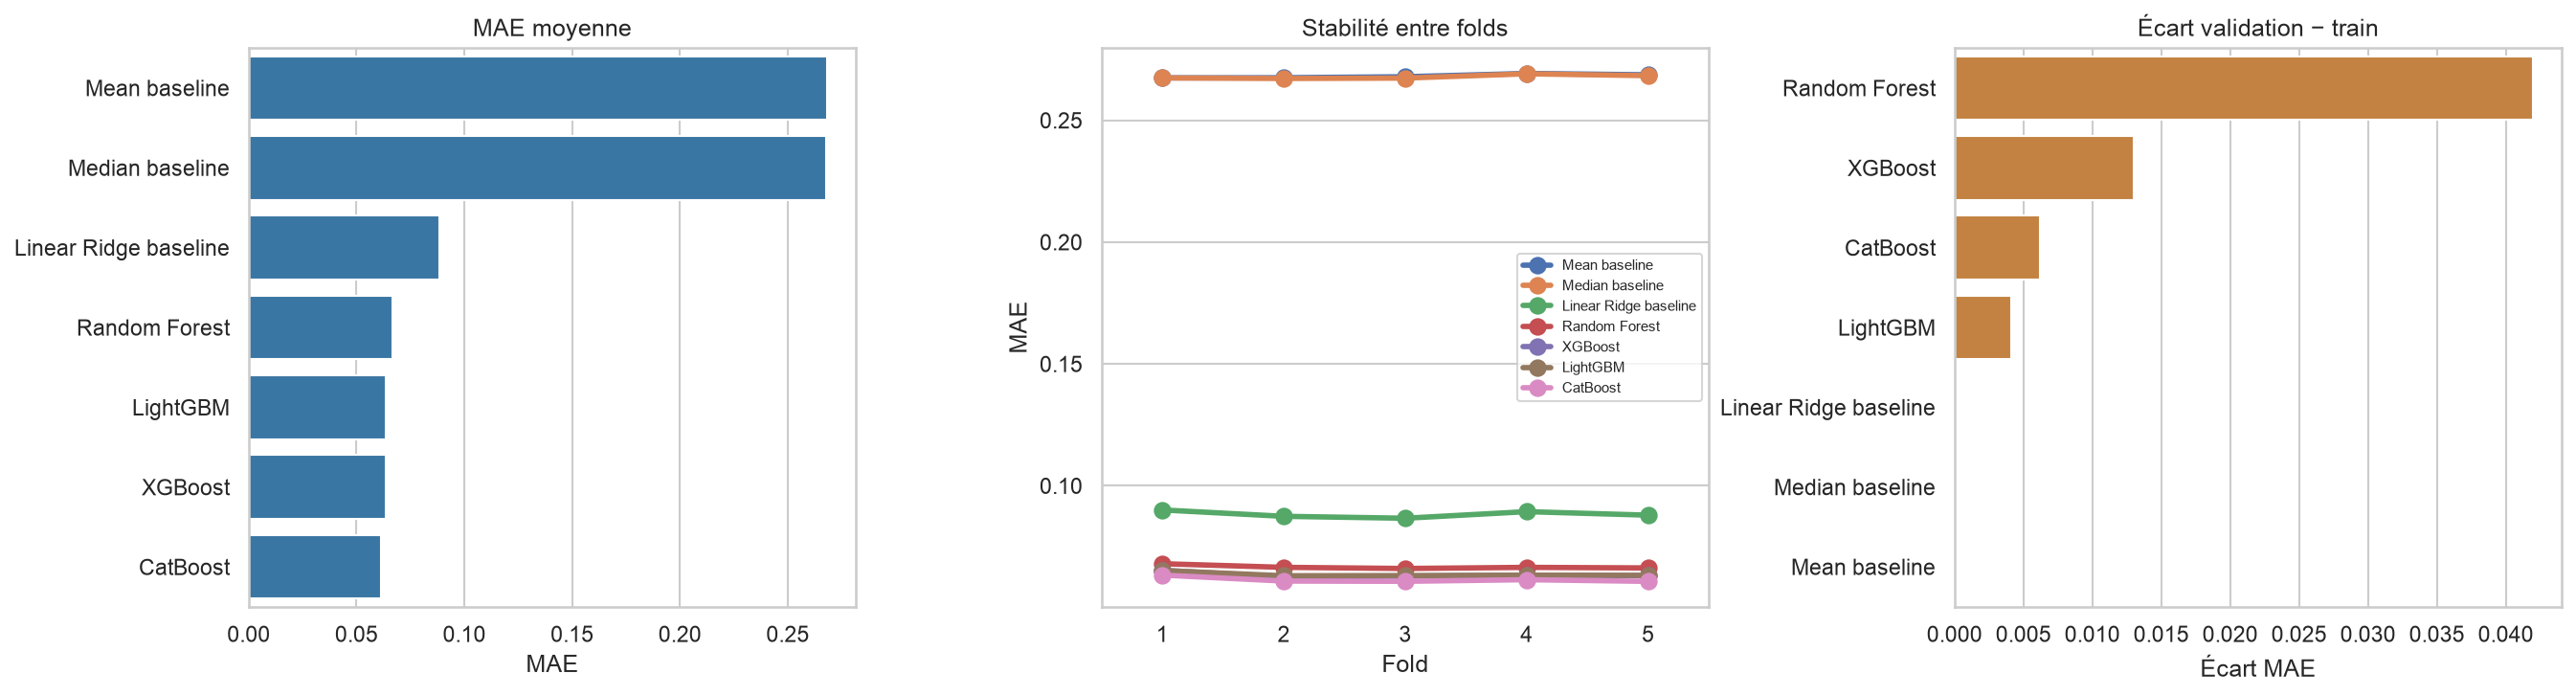

In [13]:
display(tables["initial_model_comparison"].set_index("rank"))
display(tables["model_fold_uncertainty"])
display(tables["pre_audit_configuration_comparison"])
display(Image(filename=str(results["paths"]["figure_models"])))

Les `DummyRegressor` moyenne/médiane et Ridge constituent les baselines. Les
quatre ensembles utilisent leurs hyperparamètres d'apprentissage par défaut,
avec seulement seed, parallélisme, objectif et verbosité explicités. CatBoost
bat XGBoost d'environ 0,0020 MAE et dans les cinq folds. Le rejeu des anciennes
configurations personnalisées ne donnait à XGBoost qu'un avantage de 0,000054 :
ce pré-réglage expliquait l'inversion historique du gagnant.

## 12. Tuning borné et décision anti-surajustement

,trial,random_strength,learning_rate,l2_leaf_reg,iterations,depth,border_count,mae,mae_std,train_mae,fit_seconds,predict_seconds,mae_gap
0,1,2.000000,0.050000,10.000000,1200,6,254,0.061671,0.001093,0.057417,3.537090,0.006500,0.004254
1,2,1.000000,0.080000,10.000000,1200,4,64,0.062444,0.001097,0.059170,2.481383,0.006791,0.003274
2,3,0.500000,0.030000,5.000000,800,8,64,0.062522,0.000940,0.058681,3.362913,0.009588,0.003840
3,4,1.000000,0.080000,3.000000,800,4,254,0.062679,0.001089,0.059754,1.641983,0.005113,0.002925
4,5,0.500000,0.050000,10.000000,1200,4,64,0.063085,0.001089,0.060836,2.239542,0.005573,0.002249
5,6,2.000000,0.080000,10.000000,800,4,64,0.063151,0.001083,0.060768,1.642622,0.006206,0.002383
6,7,0.500000,0.050000,1.000000,400,6,128,0.063650,0.000976,0.061304,1.062150,0.003925,0.002346
7,8,2.000000,0.030000,5.000000,400,4,64,0.070937,0.001088,0.070368,0.799339,0.003783,0.000569


,rank,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting,configuration
0,1.000000,CatBoost,0.061448,0.001095,0.060766,0.063341,0.086460,0.001895,0.920835,0.003616,0.055269,0.006180,14.675677,0.032251,16,écart modéré,CatBoost library defaults
1,NaN,CatBoost tuned,0.061671,0.001222,0.060792,0.063703,0.086746,0.002002,0.920308,0.003775,0.057417,0.004254,18.083987,0.037059,16,écart modéré,CatBoost randomized-search winner


,décision
model_family,CatBoost
baseline_mae,0.061448
best_tuned_mae,0.061671
mae_gain,-0.000223
minimum_material_gain,0.000100
accepted,False
best_parameters,"{'random_strength': 2.0, 'learning_rate': 0.05..."


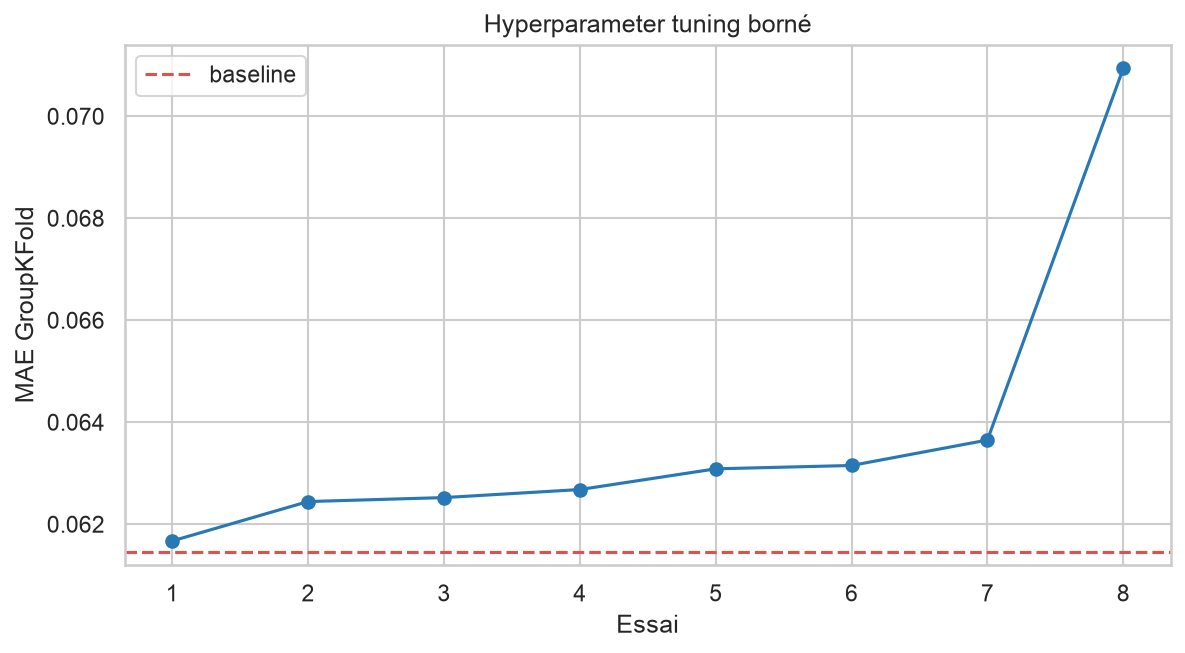

In [14]:
display(tables["tuning_trials"].sort_values("mae").head(8))
display(tables["tuning_comparison"])
display(pd.Series(results["tuning_decision"], name="décision").to_frame())
display(Image(filename=str(results["paths"]["figure_tuning"])))

Huit configurations CatBoost sont testées par `RandomizedSearchCV` sur les
mêmes folds groupés. Le meilleur essai (0,061671) dégrade la configuration par
défaut (0,061448) de 0,000223 ; le seuil de gain matériel de 0,0001 n'est pas
atteint. Le tuning est rejeté avant ouverture du holdout final.

## 13. Interprétabilité SHAP et analyse d'erreurs

,feature,mae_increase_mean,mae_increase_std
0,killRank,0.281972,0.001687
1,walk_distance_per_match_minute,0.145749,0.001787
2,kills,0.096448,0.000760
3,maxRank,0.065000,0.000892
4,walkDist,0.041945,0.000559
5,mode_duo,0.018840,0.000302
6,damage_per_kill,0.014916,0.000179
7,mode_solo,0.012782,0.000340
8,mode_squad,0.008783,0.000169
9,upgrades,0.003229,0.000089


,rank,feature,mean_abs_shap,mean_shap,positive_shap_share,explained_rows,holdout_rows
0,1,killRank,0.191275,0.016444,0.584000,2000,9872
1,2,walk_distance_per_match_minute,0.111197,-0.004707,0.452000,2000,9872
2,3,kills,0.070244,-0.012982,0.598000,2000,9872
3,4,maxRank,0.054164,0.034262,0.607500,2000,9872
4,5,walkDist,0.024768,0.001993,0.523000,2000,9872
5,6,resource_activity,0.016530,0.001196,0.444500,2000,9872
6,7,upgrades,0.013954,0.000787,0.300000,2000,9872
7,8,mode_duo,0.013696,-0.013695,0.000500,2000,9872
8,9,mode_squad,0.013422,-0.009071,0.453000,2000,9872
9,10,rideDist,0.012548,0.000227,0.211500,2000,9872


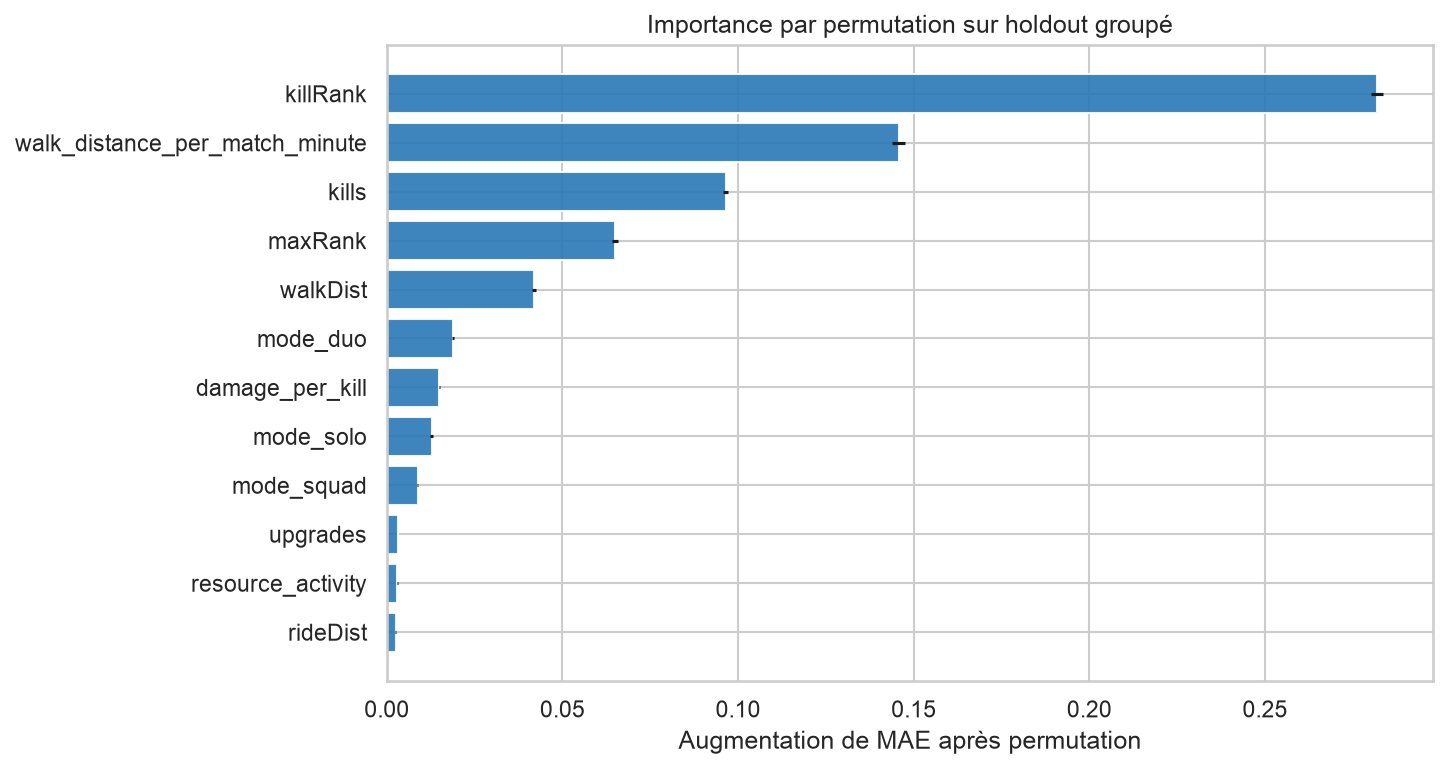

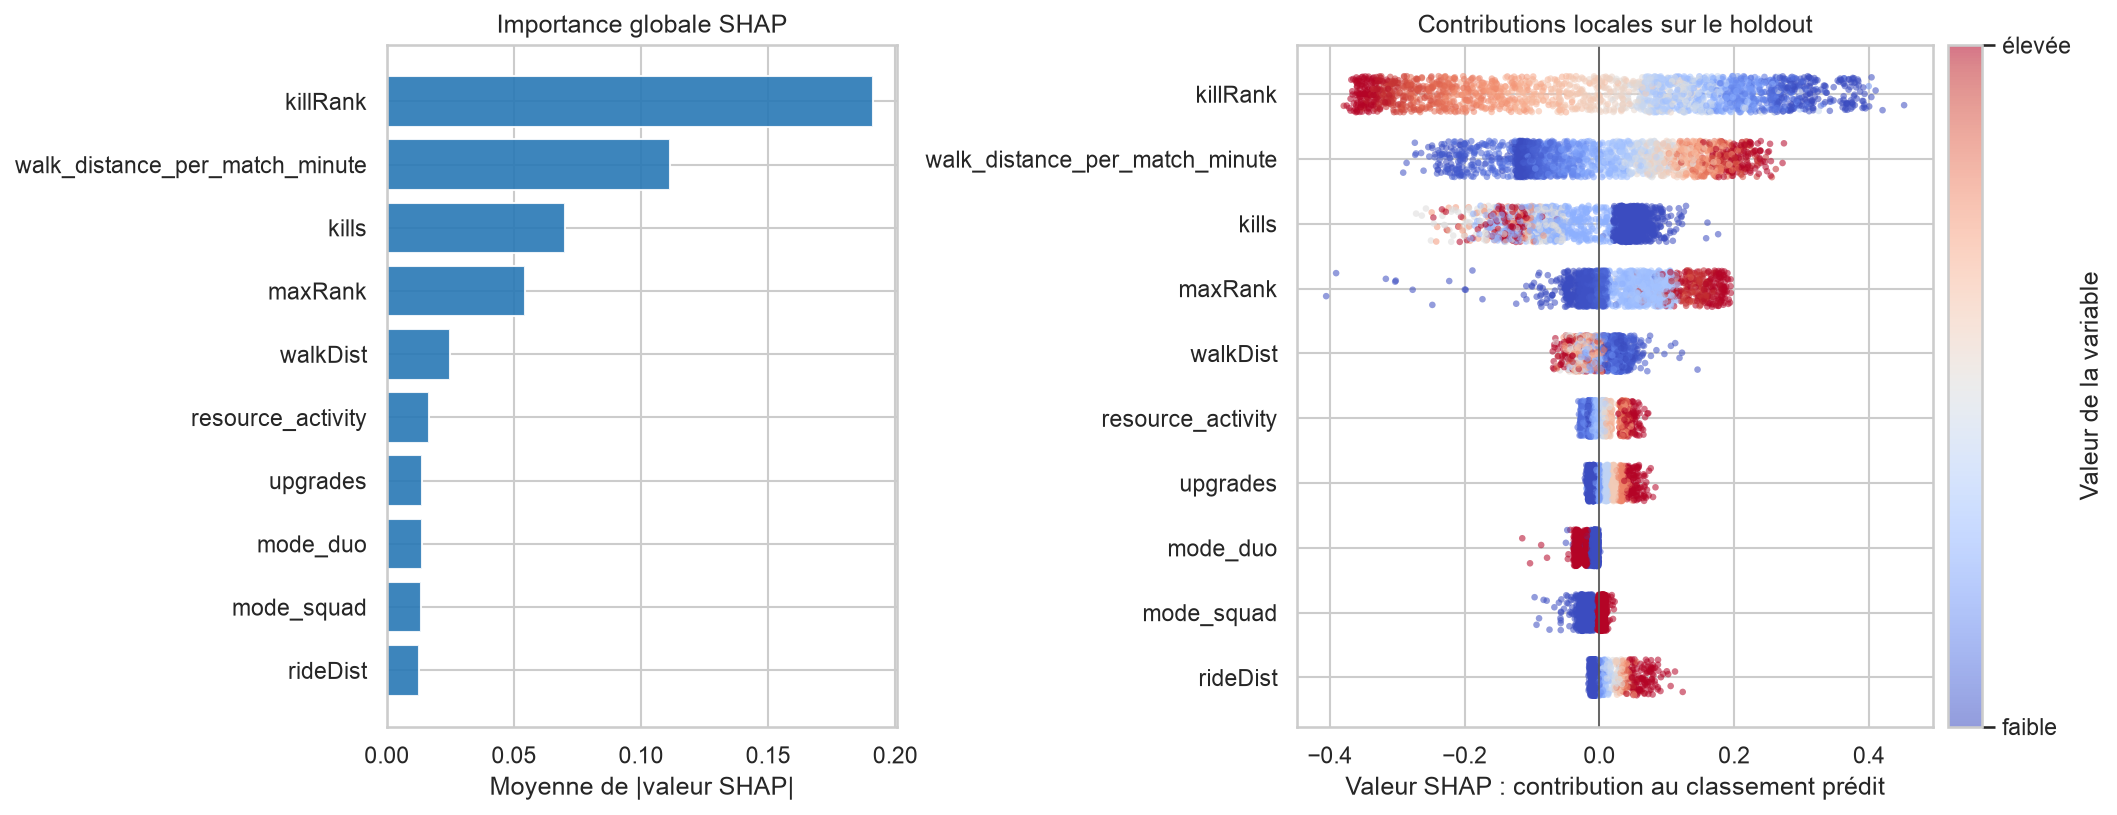

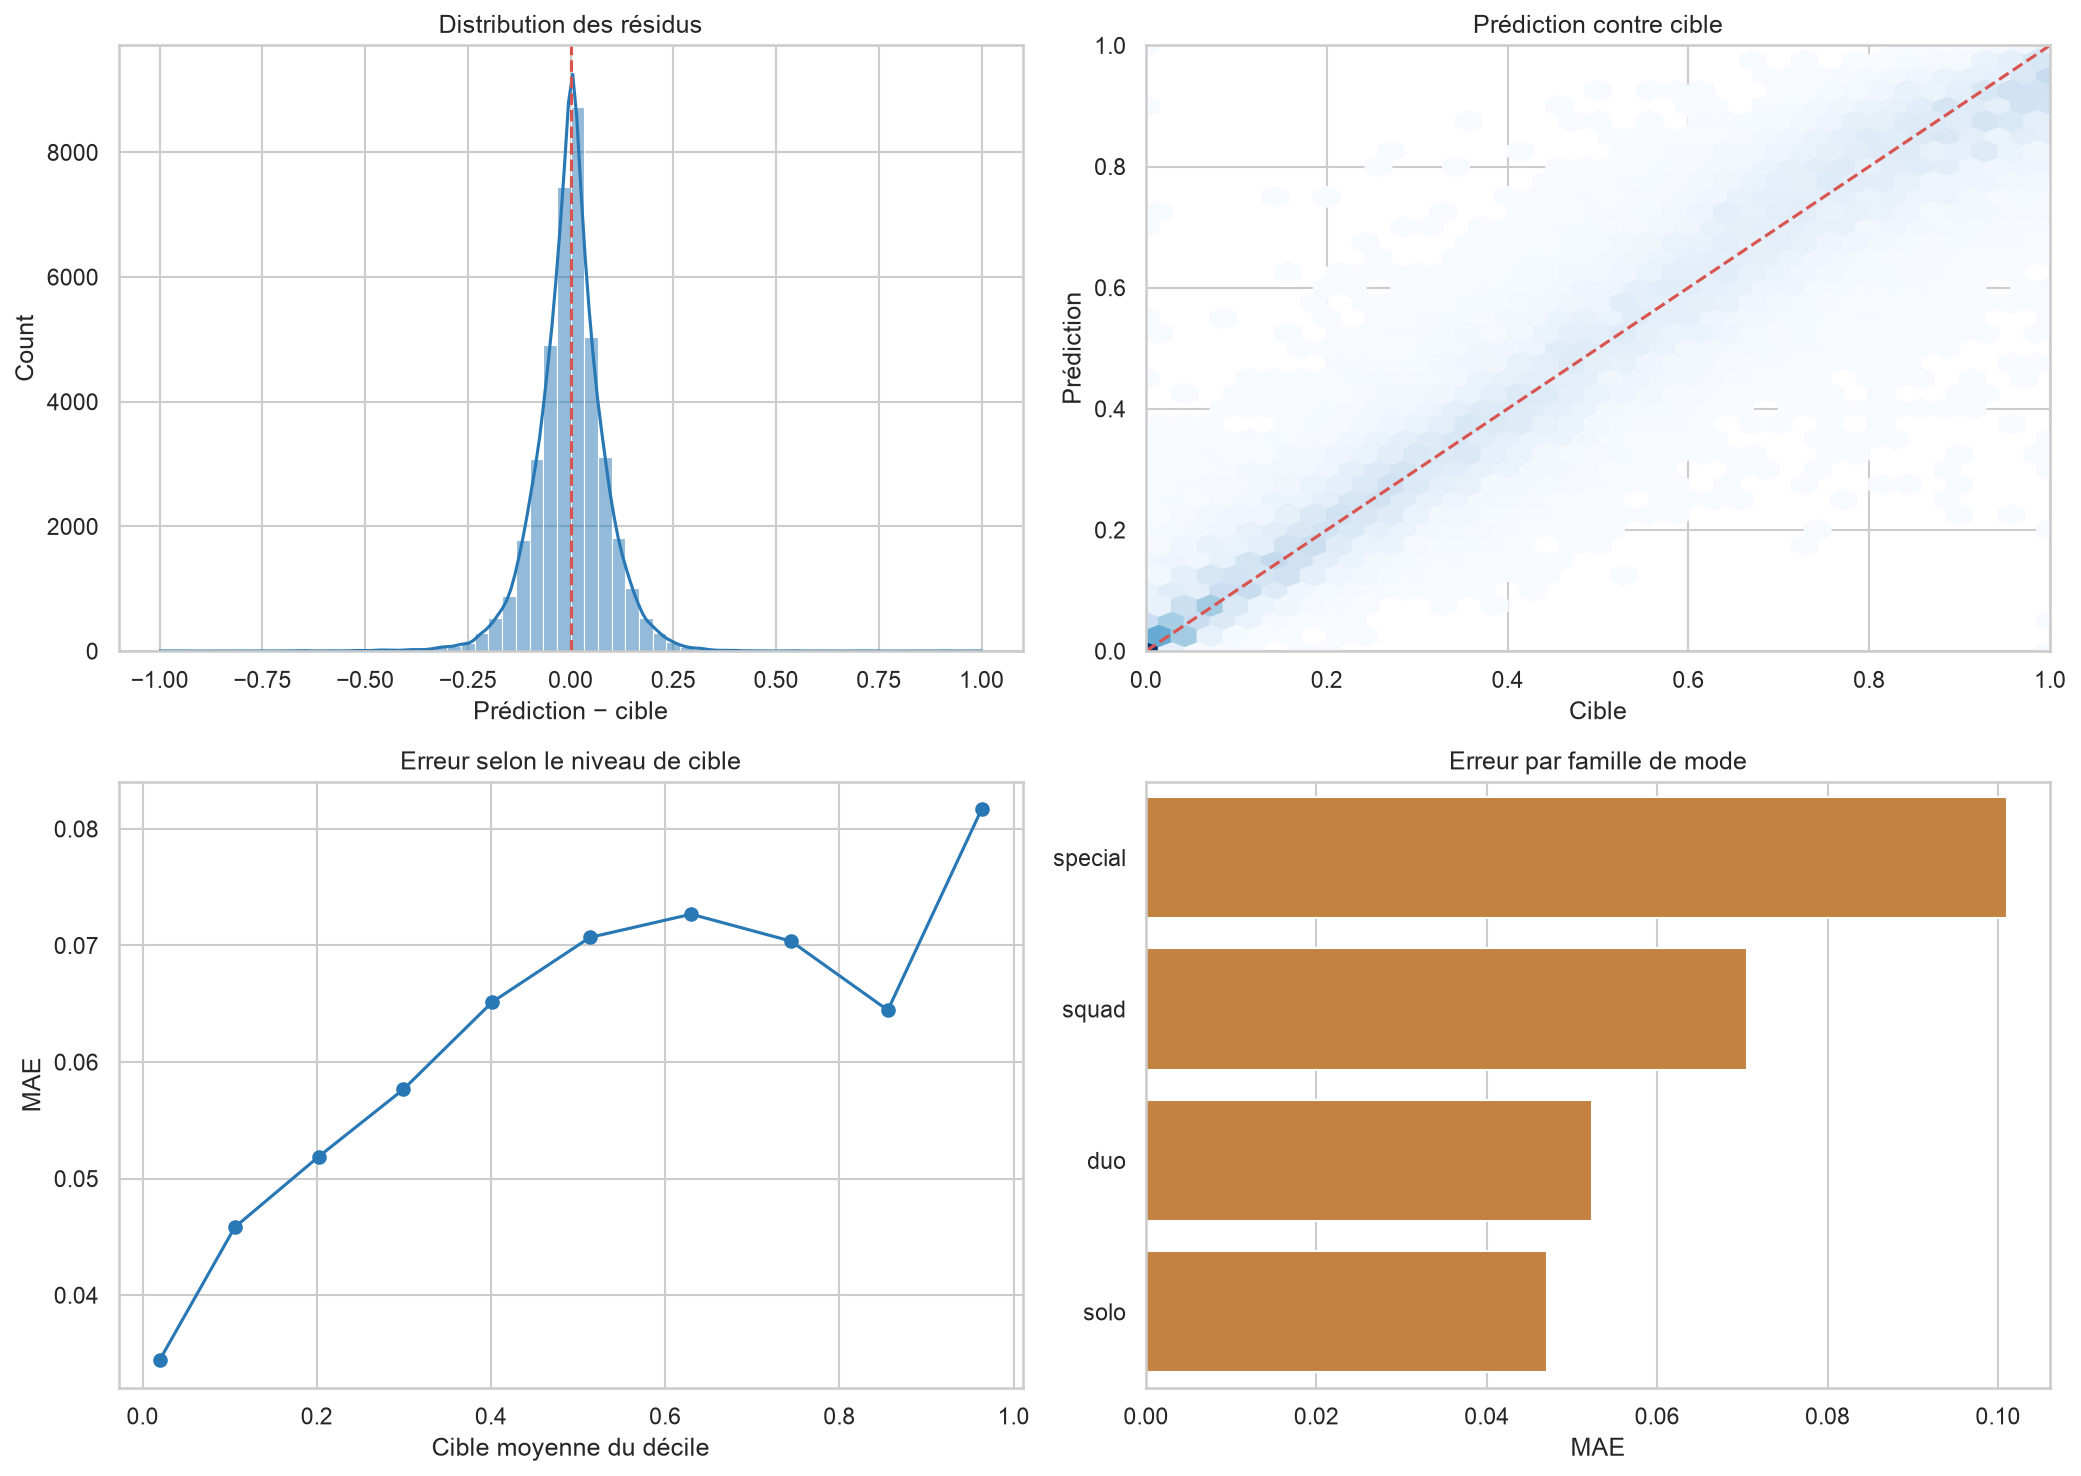

In [15]:
display(tables["permutation_importance"].head(16))
display(tables["shap_global_importance"].head(16))
display(Image(filename=str(results["paths"]["figure_importance"])))
display(Image(filename=str(results["paths"]["figure_shap"])))
display(Image(filename=str(results["paths"]["figure_errors"])))

In [16]:
important_subgroups = tables["subgroup_errors"].query(
    "dimension in ['mode_family', 'rank_grid_size', 'target_band', 'kill_band']"
)
display(important_subgroups)
display(tables["largest_errors"].head(10))

,dimension,subgroup,rows,target_mean,prediction_mean,bias,mae,rmse
0,mode_family,duo,11866,0.486204,0.486224,0.000020,0.052300,0.072228
1,mode_family,solo,6429,0.484730,0.485152,0.000422,0.047111,0.072874
2,mode_family,special,102,0.449154,0.469865,0.020711,0.101054,0.148517
3,mode_family,squad,21731,0.461461,0.461368,-0.000092,0.070500,0.096363
22,rank_grid_size,≤5,14,0.678571,0.677215,-0.001356,0.322603,0.393567
23,rank_grid_size,6–20,345,0.430793,0.434283,0.003490,0.183223,0.258874
24,rank_grid_size,21–80,33514,0.469797,0.469868,0.000070,0.063239,0.086522
25,rank_grid_size,>80,6255,0.488655,0.488577,-0.000079,0.044554,0.061827
26,target_band,0–0.1,5683,0.036334,0.066414,0.030080,0.037565,0.066164
27,target_band,0.1–0.25,6523,0.174541,0.194231,0.019690,0.049821,0.070758


,playerId,teamId,gameId,gameType,maxRank,kills,damages,walkDist,rideDist,heals,weapons,gameTime,winRankPercentage,prediction,residual,absolute_error
0,03a40fdefd4d9e,af22bc997af6bc,d0668068cfa369,solo,18,0,123.900000,0.000000,0.000000,0,7,1808,1.000000,0.000000,-1.000000,1.000000
1,bf9104d9f86113,8738398987e543,8d5c56ea372e42,solo,18,0,164.300000,0.000000,0.000000,0,7,1557,0.000000,1.000000,1.000000,1.000000
2,3063493ea78470,436d7bb11a83f4,b3dd2ad891d211,solo,19,0,21.050000,0.000000,0.000000,0,12,1808,1.000000,0.035399,-0.964601,0.964601
3,1e726bf8c7afbf,5cef1df7ee3551,01aead02bb8901,solo,20,0,119.400000,0.000000,0.000000,0,8,1808,1.000000,0.053448,-0.946552,0.946552
4,f7857a1138dd79,f128c3bd9daeec,8dbc6b52521c0f,normal-squad,2,6,964.300000,156.500000,0.000000,11,20,883,0.000000,0.910178,0.910178,0.910178
5,b4e92a23f4e2c5,8596f1ace0a0e6,278f9c9cdc08b1,solo,17,0,499.200000,0.000000,0.000000,0,8,1808,0.000000,0.905103,0.905103,0.905103
6,3d1593171f1ead,c807f2b326acae,abc9ec13d853f6,normal-duo-fpp,11,0,57.750000,0.000000,0.000000,0,2,899,1.000000,0.202266,-0.797734,0.797734
7,9a9688a47775a0,af10740c58ac13,575e7b0988d426,squad,28,4,493.300000,202.200000,0.000000,2,1,1880,0.963000,0.233766,-0.729234,0.729234
8,277115571904f6,75293ee3181ed6,7622fa844d2464,normal-squad-fpp,15,9,976.100000,"1,658.000000","1,836.000000",3,16,599,0.000000,0.722110,0.722110,0.722110
9,dde9486b06ba0b,98f8337ec1c14a,79dafc8cc6f755,solo,16,0,109.400000,0.000000,0.000000,0,10,1808,0.000000,0.713330,0.713330,0.713330


La permutation et TreeSHAP apportent deux lectures complémentaires. La
permutation mesure la perte de MAE lorsqu'une variable est mélangée ; TreeSHAP
explique le sens et l'amplitude de la contribution de chaque variable pour
chaque prédiction. CatBoost calcule TreeSHAP nativement sur 2 000 lignes tirées
de façon déterministe parmi les 9 872 lignes du holdout, après le choix du
modèle. Le pipeline vérifie que la somme des valeurs SHAP et de la valeur
attendue reconstruit chaque prédiction brute.

Les deux diagnostics placent `killRank` au premier rang, puis la marche par
minute, `kills` et `maxRank`. Sur le panneau SHAP, une contribution positive
augmente le classement prédit et une contribution négative le diminue ; la
couleur représente une valeur faible (bleu) ou élevée (rouge) **au sein de la
variable affichée**, et non une unité comparable entre variables. Ces résultats
décrivent des dépendances prédictives post-match, pas des effets causaux.

Les modes spéciaux et les petites grilles affichent les erreurs les plus hautes,
mais leurs effectifs sont faibles : ce sont des alertes, pas des conclusions
stables. Les résidus montrent une régression vers la moyenne aux cibles élevées
et quelques erreurs extrêmes ; les cas les plus difficiles sont exportés pour
inspection reproductible.

## 14. Contrat d'inférence

In [17]:
submission_check = predict_frame(
    results["test"],
    results["paths"]["model"],
)
assert list(submission_check.columns) == [
    "playerId", "teamId", "gameId", "winRankPercentage"
]
assert submission_check["winRankPercentage"].between(0, 1).all()
assert len(submission_check) == 5_000
display(submission_check.head())
display(pd.Series(results["paths"], name="chemin").tail(8).to_frame())

,playerId,teamId,gameId,winRankPercentage
0,fdb7d0af46a788,897c68f1df2b33,35ab88ab7516ad,0.833333
1,cfa5a4ed838e8f,e7d1e2c433debe,e05f33046a739f,0.750000
2,cbec92e083ebcd,52ff12219a050c,ba14752a861c4d,0.896552
3,94514c935686ac,6718223e4d7dfa,42c9e8ca738110,0.829787
4,a05a6b38045f65,372d871d4e82b7,e196ff3b6f8ced,0.608696


,chemin
figure_models,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_tuning,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_errors,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_importance,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_shap,/Users/surelmanda/GameLoft/refractor/Game-Play...
tuning_decision,/Users/surelmanda/GameLoft/refractor/Game-Play...
selection_decision,/Users/surelmanda/GameLoft/refractor/Game-Play...
submission,/Users/surelmanda/GameLoft/refractor/Game-Play...


Le bundle impose l'ordre exact des 16 features, vérifie son SHA-256 et refuse
les colonnes officielles manquantes ou les prédictions non finies. La soumission
préserve l'ordre des 5 000 lignes et contient uniquement les trois identifiants
et la cible bornée/projetée sur la grille légale.

## 15. Conclusion, limites et prochaines étapes

CatBoost par défaut atteint une MAE GroupKFold développement d'environ
**0,06145**, puis **0,06080** avec un R² de **0,92083** sur le holdout groupé du
cycle. Sans `killRank`, la MAE comportementale est d'environ **0,09266**. La
principale conclusion n'est donc pas seulement le score : `killRank` change la
nature du cas d'usage.

Limites irréductibles : test sans cible, chronologie inutilisable, couverture
très partielle des matchs/équipes, faible support de certains modes et absence
de snapshots early-game. Pour un déploiement produit, il faut collecter une
date de match cohérente, les rosters complets, un split futur réellement
étiqueté et des variables disponibles au moment précis de la décision.